# Análisis exploratorio y preparación

## Importación de librerías

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 3. Revisión de datos depurados

## 3.1. Carga y verificación de los datos depurados

In [2]:
# Cargar los datos depurados
DATA_PATH  = Path('data')
data = pd.read_pickle(DATA_PATH / 'data_processed.pkl')

data.head()

,review_id,item_id,title,text,date,review_rating,language,sentiment,name,price_interval,restaurant_rating,type
0,881374404,20112202,Cena en familia,"Pedimos una pizza para cenar, mitad barbacoa m...",2023-03-07,5,es,Positiva,66's Bar&pizzas,Moderado,4.5,"[Italian, Pizza]"
1,872226520,20112202,Que asco de restaurante,"Better pizza, mejor ponte a hacer pan que tien...",2022-12-19,1,es,Negativa,66's Bar&pizzas,Moderado,4.5,"[Italian, Pizza]"
2,850451467,20112202,"Pizzas distintas, riquísimas","Pizza de rabo de toro, conejo al ajillo,... so...",2022-07-28,5,es,Positiva,66's Bar&pizzas,Moderado,4.5,"[Italian, Pizza]"
3,810574583,20112202,ONE OF THE BEST PIZZAS,"pizza rica y distinta. calidad muy alta, el sa...",2021-09-18,5,es,Positiva,66's Bar&pizzas,Moderado,4.5,"[Italian, Pizza]"
4,757187287,20112202,Muy buenas pizzas. Tienen,Muy buenas pizzas. Tienen de varios tamaños pe...,2020-06-10,5,es,Positiva,66's Bar&pizzas,Moderado,4.5,"[Italian, Pizza]"


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1157800 entries, 0 to 1157799
Data columns (total 12 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   review_id          1157800 non-null  string        
 1   item_id            1157800 non-null  string        
 2   title              1157800 non-null  string        
 3   text               1157800 non-null  string        
 4   date               1157800 non-null  datetime64[ns]
 5   review_rating      1157800 non-null  Int64         
 6   language           1157800 non-null  category      
 7   sentiment          1157800 non-null  category      
 8   name               1157800 non-null  string        
 9   price_interval     1157800 non-null  category      
 10  restaurant_rating  1157800 non-null  Float64       
 11  type               1157800 non-null  object        
dtypes: Float64(1), Int64(1), category(3), datetime64[ns](1), object(1), string(5)
memory

In [4]:
# Resumen de calidad
quality_summary = pd.Series({
    'rows': len(data),
    'columns': data.shape[1],
    'missing_values': data.isna().sum().sum(),
    'duplicated_review_id': data['review_id'].duplicated().sum(),
    'restaurants': data['item_id'].nunique(),
    'minimum_date': data['date'].min(),
    'maximum_date': data['date'].max()
}, name='result').to_frame()

quality_summary

,result
rows,1157800
columns,12
missing_values,0
duplicated_review_id,0
restaurants,10056
minimum_date,2002-11-11 00:00:00
maximum_date,2023-06-10 00:00:00


Se cuenta con 1157800 registros, 12 variables, las reseñas son en español e inglés, no hay duplicados, no hay valores ausentes, hay 10056 restaurantes, los registros son del noviembre de 2002 a junio del 2023.

## 3.2. Unidades de análisis y variable objetivo

El proyecto utiliza tres unidades:

- **Reseña:** entrenamiento del clasificador.
- **Restaurante:** diagnóstico y alerta reputacional.
- **Grupo competitivo:** benchmarking por especialidad y precio.

`sentiment` es una etiqueta proxy derivada de `review_rating`: 1-2 = Negativa, 3 = Neutral y 4-5 = Positiva. `review_rating` y `restaurant_rating` se excluyen del clasificador para evitar fuga de información.


In [5]:
# Unidades de análisis
print(f'Reseñas: {data["review_id"].nunique():,}')
print(f'Restaurantes: {data["item_id"].nunique():,}')
print(f'Idiomas: {data["language"].nunique()}')

Reseñas: 1,157,800
Restaurantes: 10,056
Idiomas: 2


# 4. Análisis exploratorio orientado al proyecto

## 4.1. Distribución de la variable objetivo

In [6]:
# Distribución de la variable objetivo
sentiment_summary = (
    data['sentiment']
    .value_counts(sort=False)
    .rename_axis('sentiment')
    .to_frame('reviews')
)

sentiment_summary['percentage'] = (
    sentiment_summary['reviews']
    .div(sentiment_summary['reviews'].sum())
    .mul(100)
    .round(2)
)

sentiment_summary

,reviews,percentage
sentiment,,
Negativa,160177,13.83
Neutral,132627,11.46
Positiva,864996,74.71


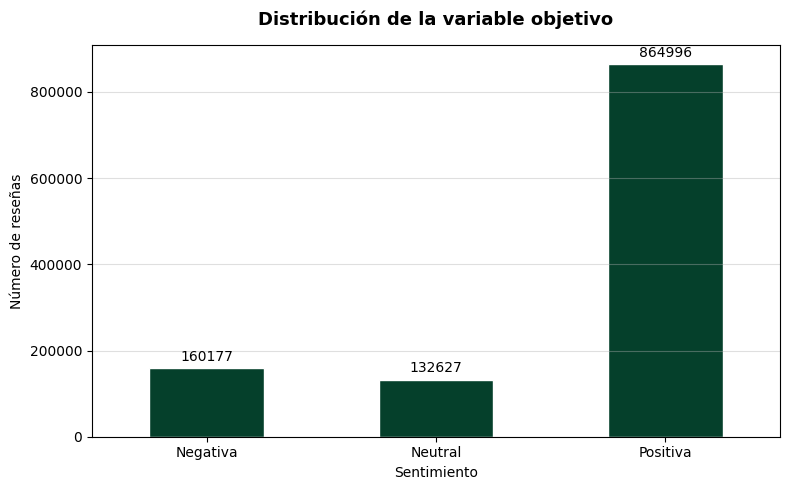

In [7]:
# Representar la distribución del sentimiento
ax = sentiment_summary['reviews'].plot(
    kind='bar',
    figsize=(8, 5),
    color='#05402B',
    edgecolor='white'
)

ax.set_title(
    'Distribución de la variable objetivo',
    fontsize=13,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Sentimiento')
ax.set_ylabel('Número de reseñas')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.4)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

La clase positiva representa el 74.71 %, la negativa el 13.83 % y la neutral el 11.46 %. Un clasificador siempre positivo alcanzaría 74.71 % de `accuracy`.

La comparación prioriza macro F1, recall negativo, balanced accuracy y matriz de confusión. El desbalance se trata con pesos de clase, sin eliminar ni sobremuestrear reseñas.


## 4.2. Características del contenido textual

In [8]:
data['title_char_count'] = data['title'].str.len()
data['text_char_count'] = data['text'].str.len()
data['text_word_count'] = data['text'].str.count(r'\S+')

In [9]:
# Resumen estadístico de las longitudes textuales
text_length_summary = (
    data[
        [
            'title_char_count',
            'text_char_count',
            'text_word_count'
        ]
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .T
    .round(2)
)

text_length_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
title_char_count,1157800.0,23.25,13.84,0.0,5.0,8.0,13.0,20.0,30.0,49.0,70.0,128.0
text_char_count,1157800.0,353.69,310.06,3.0,101.0,111.0,165.0,260.0,430.0,902.0,1557.0,15874.0
text_word_count,1157800.0,61.94,55.51,1.0,15.0,18.0,28.0,45.0,76.0,161.0,278.0,2538.0


In [10]:
# Revisar textos vacíos o extremadamente cortos
text_quality_summary = pd.Series({
    'empty_text': data['text'].str.strip().eq('').sum(),
    'up_to_3_words': data['text_word_count'].le(3).sum(),
    'up_to_5_words': data['text_word_count'].le(5).sum()
}, name='reviews').to_frame()

display(text_quality_summary)

short_reviews = data.loc[
    data['text_word_count'].le(3),
    [
        'review_id',
        'language',
        'sentiment',
        'review_rating',
        'title',
        'text',
        'text_word_count'
    ]
]

display(short_reviews.head(20))

,reviews
empty_text,0
up_to_3_words,277
up_to_5_words,502


,review_id,language,sentiment,review_rating,title,text,text_word_count
5285,15453884,es,Positiva,4,Estupendo,Estupendo,1
5287,15453844,es,Positiva,5,muy buen arabe,muy buen arabe,3
10480,15455640,en,Positiva,5,La mejor hamburguesa,La mejor hamburguesa,3
10481,15455592,es,Neutral,3,"ricas hamburguesas, ricas.","ricas hamburguesas, ricas.",3
10483,15455591,es,Positiva,4,Auténtico 100%,Auténtico 100%,2
11276,22636602,es,Positiva,4,Ricas Hamburguesas,Ricas Hamburguesas,2
11280,19416385,es,Positiva,5,MEJOR HAMBURGUESA MADRID,MEJOR HAMBURGUESA MADRID,3
11282,19260423,es,Positiva,4,Muy buenas hamburguesas!!,Muy buenas hamburguesas!!,3
11285,17045964,en,Neutral,3,super burguers,super burguers,2
13868,15456646,es,Negativa,1,Malo,Malo,1


In [11]:
# Longitud textual según el sentimiento
text_length_by_sentiment = (
    data
    .groupby('sentiment', observed=True)
    .agg(
        reviews=('review_id', 'size'),
        mean_words=('text_word_count', 'mean'),
        median_words=('text_word_count', 'median'),
        p95_words=(
            'text_word_count',
            lambda values: values.quantile(0.95)
        )
    )
    .round(2)
)

# Longitud textual según el idioma
text_length_by_language = (
    data
    .groupby('language', observed=True)
    .agg(
        reviews=('review_id', 'size'),
        mean_words=('text_word_count', 'mean'),
        median_words=('text_word_count', 'median'),
        p95_words=(
            'text_word_count',
            lambda values: values.quantile(0.95)
        )
    )
    .round(2)
)

display(text_length_by_sentiment)
display(text_length_by_language)

,reviews,mean_words,median_words,p95_words
sentiment,,,,
Negativa,160177,90.75,69.0,233
Neutral,132627,72.97,55.0,185
Positiva,864996,54.92,41.0,137


,reviews,mean_words,median_words,p95_words
language,,,,
en,199116,66.55,50.0,170
es,958684,60.99,44.0,158


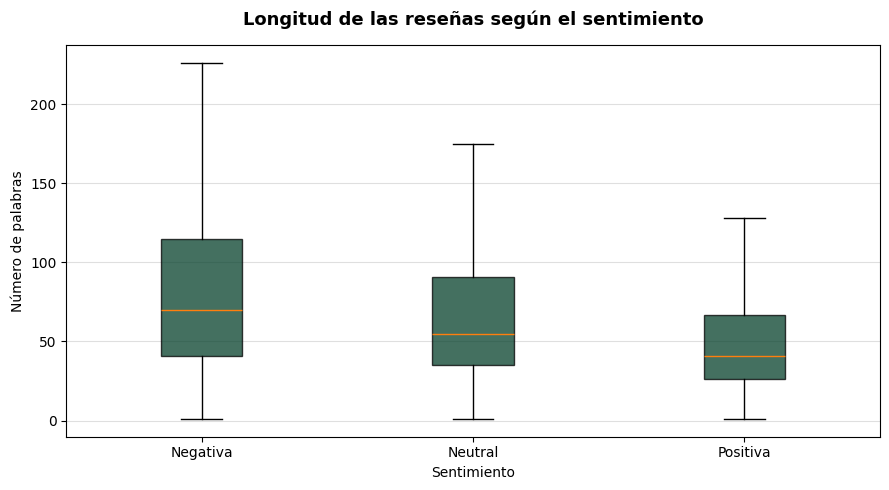

In [12]:
# Crear muestra reproducible
plot_sample = data.sample(
    n=min(100_000, len(data)),
    random_state=42
)

sentiment_order = [
    'Negativa',
    'Neutral',
    'Positiva'
]

word_count_groups = [
    plot_sample.loc[
        plot_sample['sentiment'] == sentiment,
        'text_word_count'
    ]
    for sentiment in sentiment_order
]

fig, ax = plt.subplots(figsize=(9, 5))

boxplot = ax.boxplot(
    word_count_groups,
    tick_labels=sentiment_order,
    showfliers=False,
    patch_artist=True
)

for box in boxplot['boxes']:
    box.set_facecolor('#05402B')
    box.set_alpha(0.75)

ax.set_title(
    'Longitud de las reseñas según el sentimiento',
    fontsize=13,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Sentimiento')
ax.set_ylabel('Número de palabras')
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

La reseña mediana contiene 45 palabras y la media 61.94. El 95 % no supera 161 palabras y el 99 % no supera 278; el máximo de 2,538 no justifica eliminar el registro.

No existen textos vacíos. Las reseñas de hasta cinco palabras se conservan porque contienen opiniones válidas.

La mediana es de 69 palabras en Negativa, 55 en Neutral y 41 en Positiva. En inglés es 50 y en español 44. El rendimiento se revisará por clase e idioma.

No se eliminan ni truncan textos por longitud.


## 4.3. Análisis de las reseñas por idioma

In [13]:
# Distribución de las reseñas por idioma
language_summary = (
    data['language']
    .value_counts()
    .rename_axis('language')
    .to_frame('reviews')
)

language_summary['percentage'] = (
    language_summary['reviews']
    .div(language_summary['reviews'].sum())
    .mul(100)
    .round(2)
)

language_summary

,reviews,percentage
language,,
es,958684,82.8
en,199116,17.2


In [14]:
# Frecuencia absoluta del sentimiento por idioma
language_sentiment_counts = pd.crosstab(
    data['language'],
    data['sentiment']
)

# Distribución porcentual dentro de cada idioma
language_sentiment_percentage = (
    pd.crosstab(
        data['language'],
        data['sentiment'],
        normalize='index'
    )
    .mul(100)
    .round(2)
)

display(language_sentiment_counts)
display(language_sentiment_percentage)

sentiment,Negativa,Neutral,Positiva
language,,,
en,18970,16773,163373
es,141207,115854,701623


sentiment,Negativa,Neutral,Positiva
language,,,
en,9.53,8.42,82.05
es,14.73,12.08,73.19


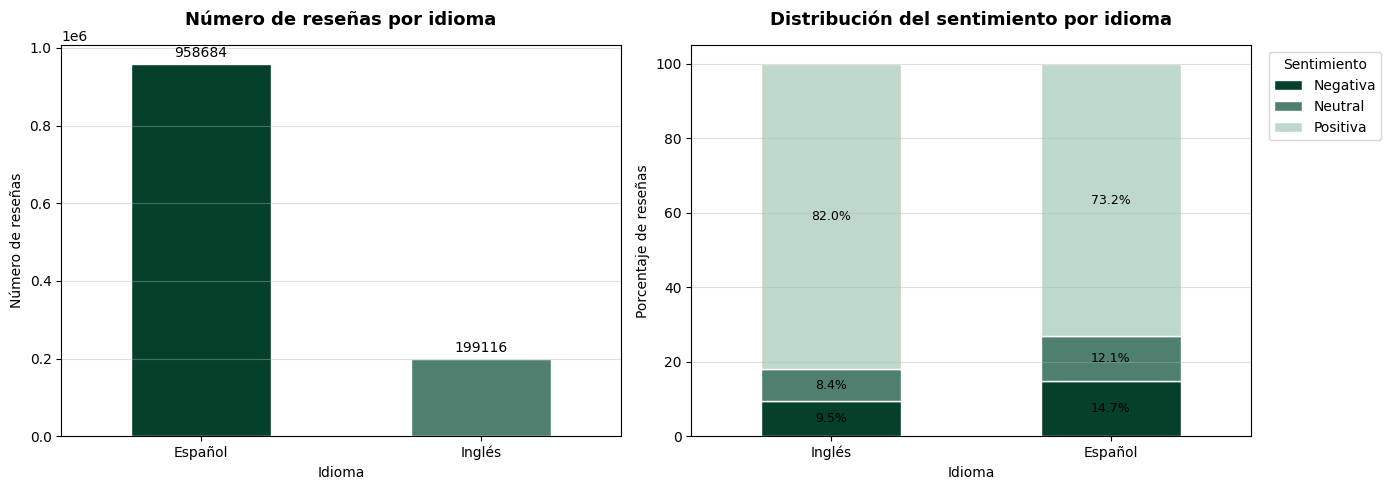

In [15]:
# Colores del proyecto
sentiment_colors = [
    '#05402B',
    '#4F7F6E',
    '#BFD8CC'
]

language_colors = [
    '#05402B',
    '#4F7F6E'
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Número de reseñas por idioma
language_summary_plot = language_summary.rename(
    index={
        'es': 'Español',
        'en': 'Inglés'
    }
)

language_summary_plot['reviews'].plot(
    kind='bar',
    ax=axes[0],
    color=language_colors,
    edgecolor='white'
)

axes[0].set_title(
    'Número de reseñas por idioma',
    fontsize=13,
    fontweight='bold',
    pad=15
)
axes[0].set_xlabel('Idioma')
axes[0].set_ylabel('Número de reseñas')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.4)

for container in axes[0].containers:
    axes[0].bar_label(container, padding=3)

# Comparar sentimiento por idioma
language_sentiment_plot = language_sentiment_percentage.rename(
    index={
        'es': 'Español',
        'en': 'Inglés'
    }
)

language_sentiment_plot.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=sentiment_colors,
    edgecolor='white'
)

axes[1].set_title(
    'Distribución del sentimiento por idioma',
    fontsize=13,
    fontweight='bold',
    pad=15
)
axes[1].set_xlabel('Idioma')
axes[1].set_ylabel('Porcentaje de reseñas')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(
    title='Sentimiento',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
axes[1].grid(axis='y', alpha=0.4)

for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt='%.1f%%',
        label_type='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [16]:
# Relación entre idioma y sentimiento
chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    language_sentiment_counts
)

n_observations = language_sentiment_counts.to_numpy().sum()
n_rows, n_columns = language_sentiment_counts.shape

cramers_v = np.sqrt(
    (chi2 / n_observations)
    / min(n_rows - 1, n_columns - 1)
)

print(f'Chi-cuadrado: {chi2:,.2f}')
print(f'Grados de libertad: {degrees_of_freedom}')
print(f'Valor p: {p_value:.6g}')
print(f'V de Cramér: {cramers_v:.4f}')

Chi-cuadrado: 6,887.71
Grados de libertad: 2
Valor p: 0
V de Cramér: 0.0771


El español representa el 82.8 % del corpus y el inglés el 17.2 %. Ambos idiomas tienen soporte suficiente.

La clase positiva alcanza 82.05 % en inglés y 73.19 % en español. Las clases negativa y neutral son más frecuentes en español.

La asociación entre idioma y sentimiento es significativa (`p < 0.001`), pero débil (V de Cramér = 0.0771). Se entrena un único clasificador bilingüe y se evalúa por idioma. No se infiere causalidad.


## 4.4. Evolución temporal de las reseñas y la reputación

## 4.4.1. Cobertura anual

In [17]:
# Crear variables temporales
data['review_year'] = data['date'].dt.year
data['year_month'] = data['date'].dt.to_period('M')

# Marcar reseñas negativas
data['is_negative'] = (
    data['sentiment']
    .eq('Negativa')
    .astype('int8')
)

In [18]:
# Evolución anual de las reseñas y la reputación
yearly_summary = (
    data
    .groupby('review_year')
    .agg(
        reviews=('review_id', 'size'),
        restaurants=('item_id', 'nunique'),
        mean_rating=('review_rating', 'mean'),
        negative_rate=('is_negative', 'mean')
    )
)

yearly_summary['negative_percentage'] = (
    yearly_summary['negative_rate']
    .mul(100)
)

yearly_summary = yearly_summary.drop(
    columns='negative_rate'
).round(2)

yearly_summary

,reviews,restaurants,mean_rating,negative_percentage
review_year,,,,
2002,1,1,5.0,0.00
2003,2,1,4.5,0.00
2004,1,1,4.0,0.00
2006,2,1,5.0,0.00
2007,333,108,3.88,7.81
2008,1371,303,3.71,13.35
2009,695,266,3.76,19.71
2010,1268,375,3.74,19.32
2011,4580,763,3.87,14.13


## 4.4.2. Serie mensual completa

In [19]:
# Agregados mensuales
monthly_summary = (
    data
    .groupby('year_month')
    .agg(
        reviews=('review_id', 'size'),
        restaurants=('item_id', 'nunique'),
        rating_sum=('review_rating', 'sum'),
        negative_reviews=('is_negative', 'sum')
    )
)

# Completar la serie mensual
complete_month_range = pd.period_range(
    start=data['year_month'].min(),
    end=data['year_month'].max(),
    freq='M'
)

monthly_summary = monthly_summary.reindex(
    complete_month_range
)

monthly_summary.index.name = 'year_month'

# Los meses sin reseñas tienen volumen cero
count_columns = [
    'reviews',
    'restaurants',
    'rating_sum',
    'negative_reviews'
]

monthly_summary[count_columns] = (
    monthly_summary[count_columns]
    .fillna(0)
)

monthly_summary['reviews'] = (
    monthly_summary['reviews']
    .astype('int64')
)

monthly_summary['restaurants'] = (
    monthly_summary['restaurants']
    .astype('int64')
)

# Métricas mensuales
monthly_summary['mean_rating'] = (
    monthly_summary['rating_sum']
    .div(monthly_summary['reviews'].replace(0, np.nan))
)

monthly_summary['negative_percentage'] = (
    monthly_summary['negative_reviews']
    .div(monthly_summary['reviews'].replace(0, np.nan))
    .mul(100)
)

monthly_summary = monthly_summary.reset_index()

monthly_summary['month'] = (
    monthly_summary['year_month']
    .dt.to_timestamp()
)

## 4.4.3. Excluir el último mes incompleto

In [20]:
# Identificar el último mes completo
last_observed_date = data['date'].max()
last_complete_month = (
    last_observed_date.to_period('M') - 1
)

complete_monthly_summary = monthly_summary.loc[
    monthly_summary['year_month'] <= last_complete_month
].copy()

print(f'Última fecha observada: {last_observed_date.date()}')
print(f'Último mes completo: {last_complete_month}')

Última fecha observada: 2023-06-10
Último mes completo: 2023-05


## 4.4.4. Periodo principal y tendencia móvil de 12 meses

In [21]:
# Definir el primer año con cobertura suficiente
minimum_annual_reviews = 10_000
minimum_annual_restaurants = 1_000

eligible_years = yearly_summary.loc[
    (yearly_summary['reviews'] >= minimum_annual_reviews)
    & (
        yearly_summary['restaurants']
        >= minimum_annual_restaurants
    )
].index

analysis_start_year = int(eligible_years.min())

# Filtrar el periodo principal
temporal_summary = complete_monthly_summary.loc[
    complete_monthly_summary['month']
    >= pd.Timestamp(
        year=analysis_start_year,
        month=1,
        day=1
    )
].copy()

# Totales móviles de los últimos 12 meses
rolling_reviews = (
    temporal_summary['reviews']
    .rolling(window=12, min_periods=12)
    .sum()
)

rolling_rating_sum = (
    temporal_summary['rating_sum']
    .rolling(window=12, min_periods=12)
    .sum()
)

rolling_negative_reviews = (
    temporal_summary['negative_reviews']
    .rolling(window=12, min_periods=12)
    .sum()
)

# Calcular métricas móviles
temporal_summary['rolling_rating_12m'] = (
    rolling_rating_sum
    .div(rolling_reviews.replace(0, np.nan))
)

temporal_summary[
    'rolling_negative_percentage_12m'
] = (
    rolling_negative_reviews
    .div(rolling_reviews.replace(0, np.nan))
    .mul(100)
)

print(
    'Primer año con cobertura suficiente:',
    analysis_start_year
)

Primer año con cobertura suficiente: 2012


## 4.4.5. Gráficos temporales

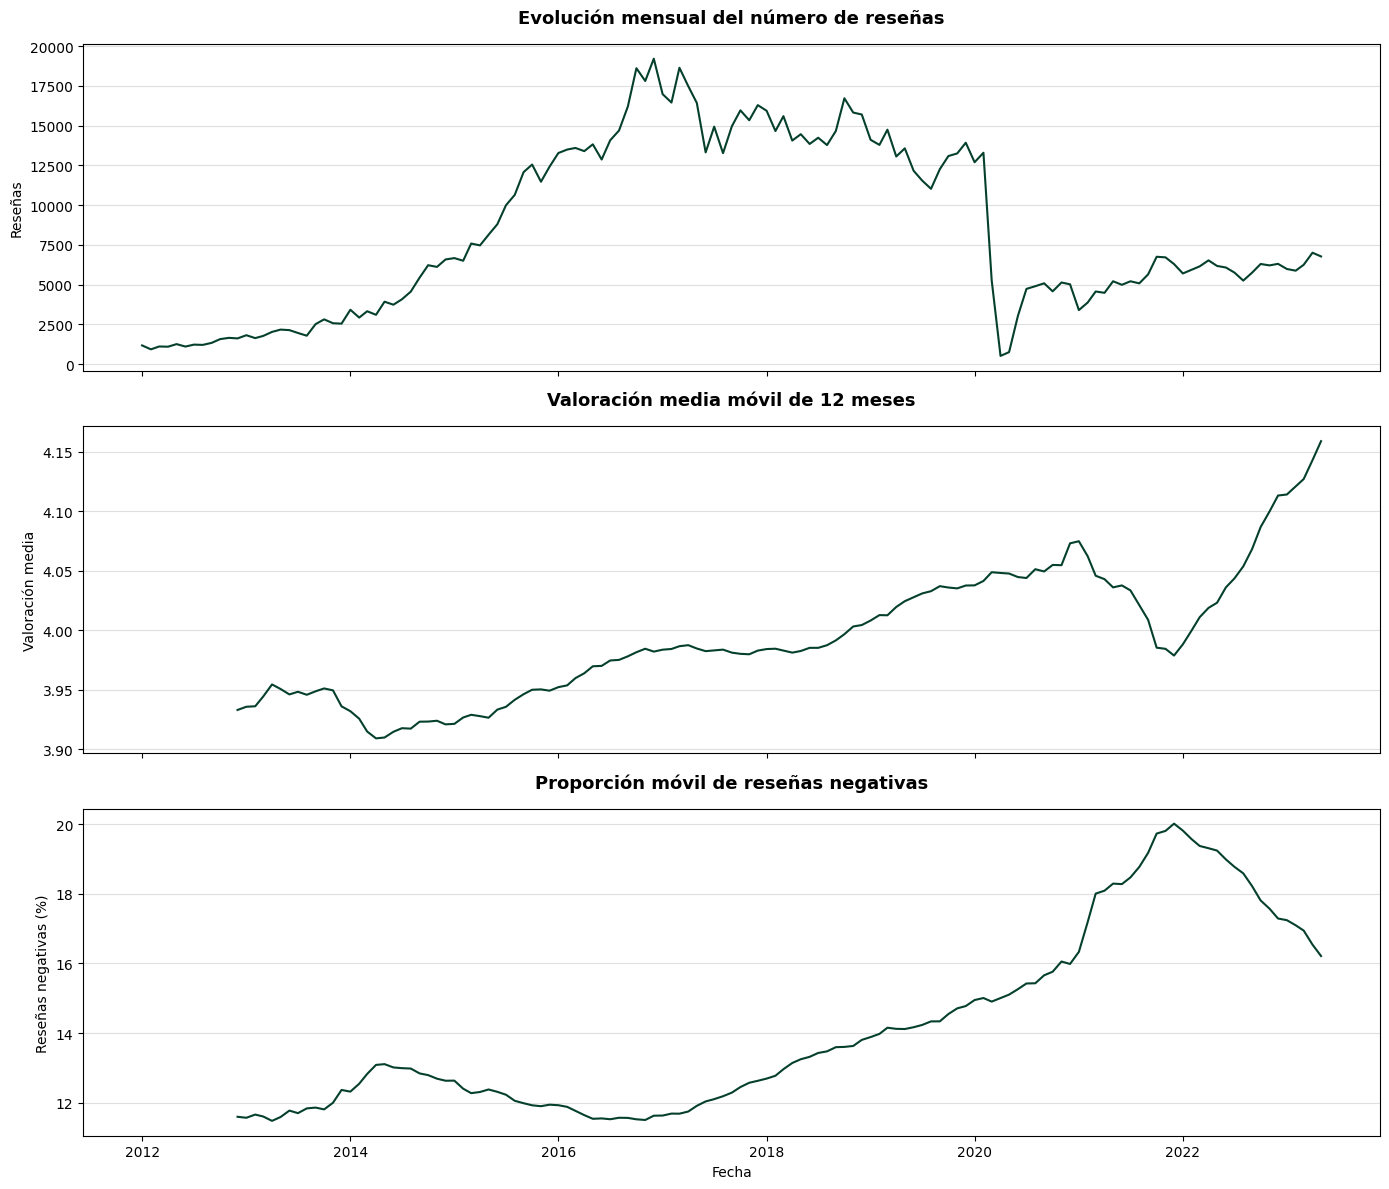

In [22]:
# Evolución temporal del volumen y la reputación
fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 12),
    sharex=True
)

# Volumen mensual
axes[0].plot(
    temporal_summary['month'],
    temporal_summary['reviews'],
    color='#05402B'
)

axes[0].set_title(
    'Evolución mensual del número de reseñas',
    fontsize=13,
    fontweight='bold',
    pad=15
)
axes[0].set_ylabel('Reseñas')
axes[0].grid(axis='y', alpha=0.4)

# Valoración móvil
axes[1].plot(
    temporal_summary['month'],
    temporal_summary['rolling_rating_12m'],
    color='#05402B'
)

axes[1].set_title(
    'Valoración media móvil de 12 meses',
    fontsize=13,
    fontweight='bold',
    pad=15
)
axes[1].set_ylabel('Valoración media')
axes[1].grid(axis='y', alpha=0.4)

# Proporción negativa móvil
axes[2].plot(
    temporal_summary['month'],
    temporal_summary['rolling_negative_percentage_12m'],
    color='#05402B'
)

axes[2].set_title(
    'Proporción móvil de reseñas negativas',
    fontsize=13,
    fontweight='bold',
    pad=15
)
axes[2].set_xlabel('Fecha')
axes[2].set_ylabel('Reseñas negativas (%)')
axes[2].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

### Conclusiones del análisis temporal

- El periodo principal comienza en 2012; los años anteriores se conservan solo por trazabilidad.
- Las reseñas aumentan hasta 190,086 en 2017 y caen 58.5 % en 2020 respecto a 2019.
- En 2021 la valoración baja a 3.98 y la proporción negativa sube a 20.01 %. En 2022 mejoran a 4.11 y 17.29 %.
- Junio de 2023 está incompleto; mayo es el último mes completo.
- Valoración media y proporción negativa proceden de la misma puntuación y no son evidencias independientes.

Los resultados son descriptivos y no permiten atribuir causas.


## 4.5. Relación entre el rango de precio y la reputación

El rango de precio se analiza desde dos perspectivas: el número de
restaurantes y el número de reseñas. Esta distinción evita que los
restaurantes con mayor actividad tengan un peso excesivo al describir la
oferta disponible.

La categoría `Sin información` se conserva para cuantificar la falta de
cobertura, pero no se interpreta como un rango de precio real.

`price_interval` se utilizará posteriormente para construir los grupos de
benchmarking competitivo, pero no como predictor del clasificador de
sentimiento.

### 4.5.1. Construcción del catálogo único de restaurantes

Para describir la oferta por rango de precio se construye primero un catálogo
con una observación por restaurante. De esta manera, los establecimientos con
más reseñas no reciben un peso mayor en la distribución.

In [23]:
# Orden lógico de los rangos de precio
price_order = [
    'Económico',
    'Moderado',
    'Premium',
    'Sin información'
]

# Crear catálogo de restaurantes
restaurant_catalog = (
    data[
        [
            'item_id',
            'name',
            'price_interval',
            'restaurant_rating'
        ]
    ]
    .drop_duplicates(subset='item_id')
    .copy()
)

# Validar el catálogo
catalog_validation = pd.Series({
    'rows': len(restaurant_catalog),
    'unique_restaurants': (
        restaurant_catalog['item_id'].nunique()
    ),
    'duplicated_item_id': (
        restaurant_catalog['item_id'].duplicated().sum()
    ),
    'missing_price': (
        restaurant_catalog['price_interval'].isna().sum()
    )
}, name='result').to_frame()

catalog_validation

,result
rows,10056
unique_restaurants,10056
duplicated_item_id,0
missing_price,0


### 4.5.2. Distribución de restaurantes por rango de precio

In [24]:
# Distribución de restaurantes por rango de precio
restaurant_price_summary = (
    restaurant_catalog['price_interval']
    .value_counts(sort=False)
    .reindex(price_order, fill_value=0)
    .rename_axis('price_interval')
    .to_frame('restaurants')
)

restaurant_price_summary['percentage'] = (
    restaurant_price_summary['restaurants']
    .div(restaurant_price_summary['restaurants'].sum())
    .mul(100)
    .round(2)
)

display(restaurant_price_summary)

print(
    'Total de restaurantes:',
    f"{restaurant_price_summary['restaurants'].sum():,}"
)

,restaurants,percentage
price_interval,,
Económico,2057,20.46
Moderado,5202,51.73
Premium,328,3.26
Sin información,2469,24.55


Total de restaurantes: 10,056


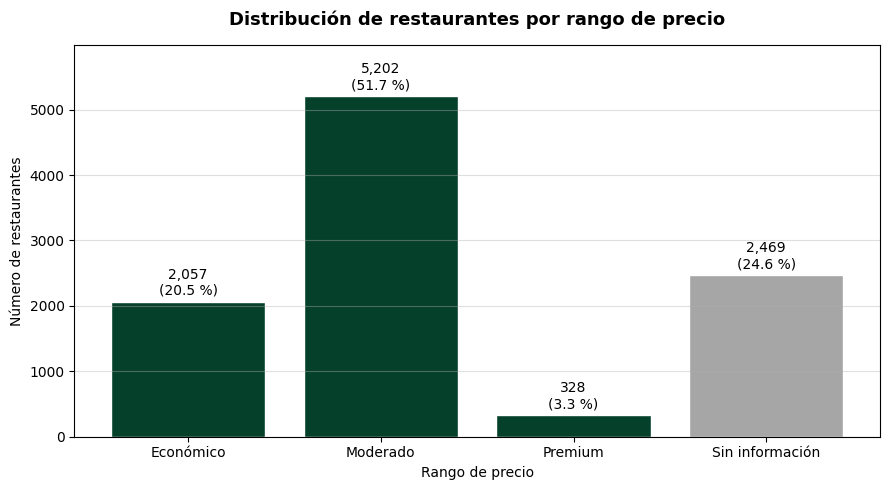

In [25]:
# Preparar los datos para la visualización
price_plot = restaurant_price_summary.reset_index()

price_colors = [
    '#05402B',
    '#05402B',
    '#05402B',
    '#A6A6A6'
]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    price_plot['price_interval'],
    price_plot['restaurants'],
    color=price_colors,
    edgecolor='white'
)

bar_labels = [
    f'{int(restaurants):,}\n({percentage:.1f} %)'
    for restaurants, percentage in zip(
        price_plot['restaurants'],
        price_plot['percentage']
    )
]

ax.bar_label(
    bars,
    labels=bar_labels,
    padding=3
)

ax.set_title(
    'Distribución de restaurantes por rango de precio',
    fontsize=13,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Rango de precio')
ax.set_ylabel('Número de restaurantes')
ax.set_ylim(
    0,
    price_plot['restaurants'].max() * 1.15
)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

Moderado concentra 5,202 restaurantes (51.73 %), Económico 2,057 (20.46 %) y Premium 328 (3.26 %).

El precio está disponible para 7,587 restaurantes (75.45 %). Los 2,469 restantes se mantienen como `Sin información`.

Premium se conserva. Los restaurantes sin precio participan en el análisis general, pero no en comparaciones por rango.


### 4.5.3. Distribución de las reseñas por rango de precio

Además de estudiar cuántos restaurantes pertenecen a cada categoría, se
analiza el volumen de reseñas generado por cada rango de precio. También se
calcula la actividad media y mediana por restaurante para detectar posibles
diferencias de participación.

In [26]:
# Contar reseñas por restaurante
reviews_per_restaurant = (
    data
    .groupby(
        ['price_interval', 'item_id'],
        observed=True
    )
    .size()
    .rename('reviews_per_restaurant')
    .reset_index()
)

# Resumir la actividad por rango de precio
review_price_summary = (
    reviews_per_restaurant
    .groupby('price_interval', observed=True)
    .agg(
        restaurants=('item_id', 'size'),
        reviews=('reviews_per_restaurant', 'sum'),
        mean_reviews_per_restaurant=(
            'reviews_per_restaurant',
            'mean'
        ),
        median_reviews_per_restaurant=(
            'reviews_per_restaurant',
            'median'
        )
    )
    .reindex(price_order)
)

review_price_summary['review_percentage'] = (
    review_price_summary['reviews']
    .div(review_price_summary['reviews'].sum())
    .mul(100)
)

review_price_summary = review_price_summary[
    [
        'restaurants',
        'reviews',
        'review_percentage',
        'mean_reviews_per_restaurant',
        'median_reviews_per_restaurant'
    ]
].round(2)

display(review_price_summary)

print(
    'Total de reseñas:',
    f"{int(review_price_summary['reviews'].sum()):,}"
)

,restaurants,reviews,review_percentage,mean_reviews_per_restaurant,median_reviews_per_restaurant
price_interval,,,,,
Económico,2057,148307,12.81,72.10,23.0
Moderado,5202,881185,76.11,169.39,56.0
Premium,328,105637,9.12,322.06,142.0
Sin información,2469,22671,1.96,9.18,4.0


Total de reseñas: 1,157,800


### 4.5.4. Comparación entre oferta y actividad por precio

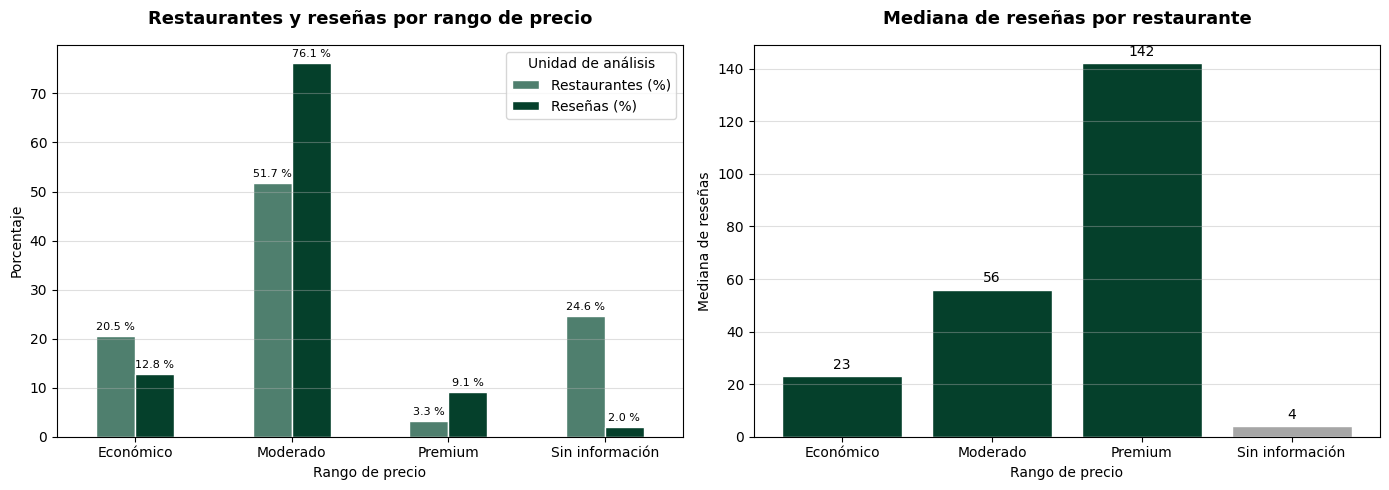

In [27]:
# Comparar la proporción de restaurantes y reseñas
price_comparison = pd.DataFrame({
    'Restaurantes (%)': (
        restaurant_price_summary['percentage']
    ),
    'Reseñas (%)': (
        review_price_summary['review_percentage']
    )
}).reindex(price_order)

price_category_colors = [
    '#05402B',
    '#05402B',
    '#05402B',
    '#A6A6A6'
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Comparación entre oferta y actividad
price_comparison.plot(
    kind='bar',
    ax=axes[0],
    color=['#4F7F6E', '#05402B'],
    edgecolor='white'
)

axes[0].set_title(
    'Restaurantes y reseñas por rango de precio',
    fontsize=13,
    fontweight='bold',
    pad=15
)
axes[0].set_xlabel('Rango de precio')
axes[0].set_ylabel('Porcentaje')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Unidad de análisis')
axes[0].grid(axis='y', alpha=0.4)

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt='%.1f %%',
        padding=3,
        fontsize=8
    )

# Actividad mediana por restaurante
median_activity = review_price_summary[
    'median_reviews_per_restaurant'
]

bars = axes[1].bar(
    median_activity.index,
    median_activity.values,
    color=price_category_colors,
    edgecolor='white'
)

axes[1].bar_label(
    bars,
    fmt='%.0f',
    padding=3
)

axes[1].set_title(
    'Mediana de reseñas por restaurante',
    fontsize=13,
    fontweight='bold',
    pad=15
)
axes[1].set_xlabel('Rango de precio')
axes[1].set_ylabel('Mediana de reseñas')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

Moderado reúne el 51.73 % de los restaurantes y el 76.11 % de las reseñas. Premium representa el 3.26 % de los restaurantes y el 9.12 % de las reseñas, con la mayor mediana por establecimiento: 142.

`Sin información` agrupa el 24.55 % de los restaurantes, pero solo el 1.96 % de las reseñas. Los precios conocidos cubren el 98.04 % de las reseñas.

En todos los rangos la media supera la mediana, por lo que el benchmarking exige tamaños mínimos y usa estadísticas robustas. Las diferencias son descriptivas, no causales.


### 4.5.5. Distribución del sentimiento según el rango de precio

La relación entre precio y sentimiento se analiza únicamente para los
restaurantes con un rango de precio conocido. Los porcentajes se calculan
dentro de cada categoría para evitar que el diferente volumen de reseñas
distorsione la comparación.

In [28]:
# Seleccionar solamente rangos de precio conocidos
known_price_order = [
    'Económico',
    'Moderado',
    'Premium'
]

known_price_data = data.loc[
    data['price_interval'].isin(known_price_order)
].copy()

# Frecuencias absolutas
price_sentiment_counts = (
    pd.crosstab(
        known_price_data['price_interval'],
        known_price_data['sentiment']
    )
    .reindex(
        index=known_price_order,
        columns=sentiment_order
    )
)

# Porcentajes dentro de cada rango de precio
price_sentiment_percentage = (
    pd.crosstab(
        known_price_data['price_interval'],
        known_price_data['sentiment'],
        normalize='index'
    )
    .mul(100)
    .reindex(
        index=known_price_order,
        columns=sentiment_order
    )
    .round(2)
)

display(price_sentiment_counts)
display(price_sentiment_percentage)

known_price_reviews = (
    price_sentiment_counts
    .to_numpy()
    .sum()
)

print(
    'Reseñas con precio conocido:',
    f'{known_price_reviews:,}'
)

print(
    'Cobertura sobre el total:',
    f'{known_price_reviews / len(data) * 100:.2f} %'
)

sentiment,Negativa,Neutral,Positiva
price_interval,,,
Económico,22440,18338,107529
Moderado,121070,100542,659573
Premium,12622,12001,81014


sentiment,Negativa,Neutral,Positiva
price_interval,,,
Económico,15.13,12.36,72.50
Moderado,13.74,11.41,74.85
Premium,11.95,11.36,76.69


Reseñas con precio conocido: 1,135,129
Cobertura sobre el total: 98.04 %


### 4.5.6. Visualización del sentimiento según el rango de precio

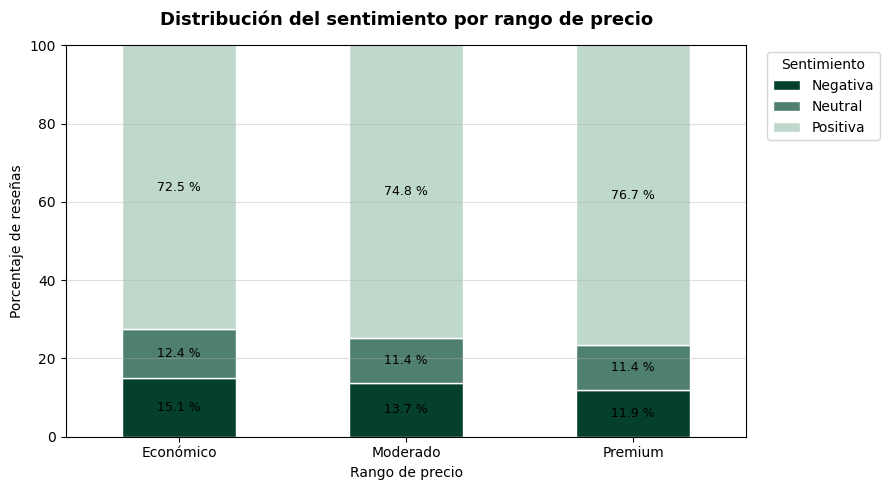

In [29]:
# Graficar sentimiento
fig, ax = plt.subplots(figsize=(9, 5))

price_sentiment_percentage.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=sentiment_colors,
    edgecolor='white'
)

ax.set_title(
    'Distribución del sentimiento por rango de precio',
    fontsize=13,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Rango de precio')
ax.set_ylabel('Porcentaje de reseñas')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=0)
ax.legend(
    title='Sentimiento',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)
ax.grid(axis='y', alpha=0.4)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f %%',
        label_type='center',
        fontsize=9
    )


plt.tight_layout()


plt.show()

### 4.5.7. Asociación estadística entre precio y sentimiento

In [30]:
# Evaluar la asociación entre precio y sentimiento
chi2, p_value, degrees_of_freedom, expected = (
    chi2_contingency(price_sentiment_counts)
)

n_observations = price_sentiment_counts.to_numpy().sum()
n_rows, n_columns = price_sentiment_counts.shape

cramers_v = np.sqrt(
    (chi2 / n_observations)
    / min(n_rows - 1, n_columns - 1)
)

print(f'Chi-cuadrado: {chi2:,.2f}')
print(f'Grados de libertad: {degrees_of_freedom}')
print(
    'Valor p:',
    '< 0.001' if p_value < 0.001
    else f'{p_value:.3f}'
)
print(f'V de Cramér: {cramers_v:.4f}')
print(
    'Frecuencia esperada mínima:',
    f'{expected.min():,.2f}'
)

Chi-cuadrado: 712.58
Grados de libertad: 4
Valor p: < 0.001
V de Cramér: 0.0177
Frecuencia esperada mínima: 12,180.00


La proporción negativa baja del 15.13 % en Económico al 11.95 % en Premium; la positiva sube del 72.50 % al 76.69 %.

La asociación es significativa (`p < 0.001`), pero extremadamente débil (V de Cramér = 0.0177). `price_interval` se usa para benchmarking, no como predictor.

Como `sentiment` deriva de `review_rating`, el resultado describe una etiqueta proxy y no demuestra causalidad.


## 4.6. Análisis de especialidades gastronómicas

La variable `type` es multietiqueta: un mismo restaurante puede pertenecer a
varias especialidades gastronómicas. Por ello, el número total de asignaciones
puede ser superior al número de restaurantes.

El análisis se realizará primero con una observación por restaurante. No se
expandirá directamente el dataset de reseñas, porque hacerlo duplicaría las
reseñas de los restaurantes con varias especialidades y distorsionaría los
resultados.

### 4.6.1. Validación de la variable multietiqueta

In [31]:
# Crear catálogo de especialidades
restaurant_specialty_catalog = (
    data[
        [
            'item_id',
            'name',
            'price_interval',
            'restaurant_rating',
            'type'
        ]
    ]
    .drop_duplicates(subset='item_id')
    .copy()
)

# Comprobar que todos los valores sean listas
is_list = restaurant_specialty_catalog['type'].map(
    lambda values: isinstance(values, list)
)

specialty_count = restaurant_specialty_catalog['type'].map(
    lambda values: len(values)
    if isinstance(values, list)
    else 0
)

specialty_validation = pd.Series({
    'restaurants': len(restaurant_specialty_catalog),
    'unique_restaurants': (
        restaurant_specialty_catalog['item_id'].nunique()
    ),
    'non_list_values': (~is_list).sum(),
    'empty_lists': specialty_count.eq(0).sum(),
    'restaurants_without_specialty_information': (
        restaurant_specialty_catalog['type']
        .map(
            lambda values: (
                'Sin información' in values
                if isinstance(values, list)
                else False
            )
        )
        .sum()
    ),
    'total_specialty_assignments': specialty_count.sum(),
    'mean_specialties_per_restaurant': specialty_count.mean(),
    'restaurants_with_repeated_specialty': (
        restaurant_specialty_catalog['type']
        .map(
            lambda values: (
                len(values) != len(set(values))
                if isinstance(values, list)
                else False
            )
        )
        .sum()
    )
}, name='result').to_frame()

specialty_validation.round(2)

,result
restaurants,10056.00
unique_restaurants,10056.00
non_list_values,0.00
empty_lists,0.00
restaurants_without_specialty_information,1172.00
total_specialty_assignments,16278.00
mean_specialties_per_restaurant,1.62
restaurants_with_repeated_specialty,0.00


### 4.6.2. Expansión de las especialidades por restaurante

Se construye una tabla independiente donde cada fila representa una
combinación restaurante–especialidad. El dataset original `data` no se
modifica, evitando así duplicar las reseñas.

In [32]:
# Crear una tabla restaurante-especialidad
restaurant_specialty = (
    restaurant_specialty_catalog
    .explode(
        column='type',
        ignore_index=True
    )
    .rename(columns={'type': 'specialty'})
)

# Normalizar el tipo de la especialidad
restaurant_specialty['specialty'] = (
    restaurant_specialty['specialty']
    .astype('string')
    .str.strip()
)

# Validar la expansión
expanded_specialty_validation = pd.Series({
    'rows': len(restaurant_specialty),
    'unique_restaurants': (
        restaurant_specialty['item_id'].nunique()
    ),
    'missing_specialty': (
        restaurant_specialty['specialty'].isna().sum()
    ),
    'empty_specialty': (
        restaurant_specialty['specialty'].eq('').sum()
    ),
    'duplicated_restaurant_specialty': (
        restaurant_specialty
        .duplicated(
            subset=['item_id', 'specialty']
        )
        .sum()
    ),
    'assignments_without_information': (
        restaurant_specialty['specialty']
        .eq('Sin información')
        .sum()
    )
}, name='result').to_frame()

expanded_specialty_validation

,result
rows,16278
unique_restaurants,10056
missing_specialty,0
empty_specialty,0
duplicated_restaurant_specialty,0
assignments_without_information,1172


### 4.6.3. Distribución de restaurantes por especialidad

La categoría `Sin información` se excluye del ranking porque no representa una
especialidad gastronómica. La frecuencia se calcula mediante restaurantes
únicos, no mediante reseñas.

In [33]:
# Conservar solamente especialidades conocidas
known_restaurant_specialty = (
    restaurant_specialty.loc[
        restaurant_specialty['specialty']
        .ne('Sin información')
    ]
    .copy()
)

known_specialty_restaurants = (
    known_restaurant_specialty['item_id']
    .nunique()
)

# Número de restaurantes por especialidad
specialty_summary = (
    known_restaurant_specialty
    .groupby('specialty')
    .agg(
        restaurants=('item_id', 'nunique')
    )
    .sort_values(
        by='restaurants',
        ascending=False
    )
)

specialty_summary[
    'percentage_known_restaurants'
] = (
    specialty_summary['restaurants']
    .div(known_specialty_restaurants)
    .mul(100)
    .round(2)
)

display(specialty_summary.head(20))

print(
    'Especialidades diferentes:',
    f'{len(specialty_summary):,}'
)

print(
    'Restaurantes con especialidad conocida:',
    f'{known_specialty_restaurants:,}'
)

print(
    'Asignaciones de especialidad conocidas:',
    f'{len(known_restaurant_specialty):,}'
)

,restaurants,percentage_known_restaurants
specialty,,
Spanish,3615,40.69
Mediterranean,2447,27.54
Cafe,806,9.07
European,686,7.72
Bar,653,7.35
Italian,575,6.47
American,460,5.18
Coffee & Tea,392,4.41
Japanese,379,4.27


Especialidades diferentes: 113
Restaurantes con especialidad conocida: 8,884
Asignaciones de especialidad conocidas: 15,106


### 4.6.4. Especialidades gastronómicas más representadas

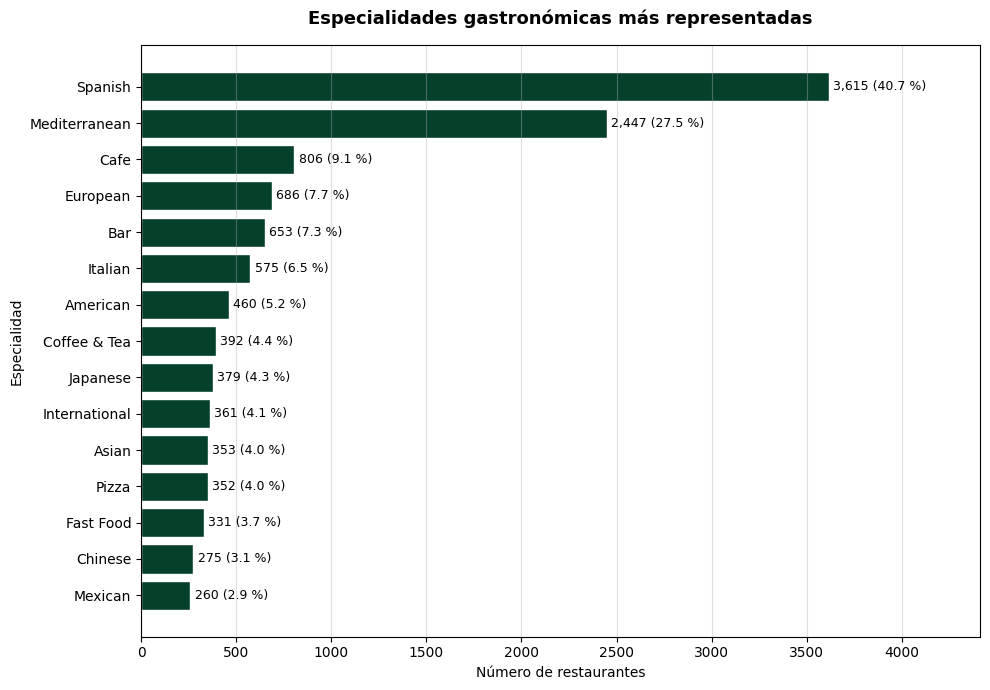

In [34]:
# Seleccionar las 15 principales
top_n_specialties = 15

top_specialties = (
    specialty_summary
    .head(top_n_specialties)
    .sort_values(
        by='restaurants',
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    top_specialties.index,
    top_specialties['restaurants'],
    color='#05402B',
    edgecolor='white'
)

bar_labels = [
    f'{int(restaurants):,} ({percentage:.1f} %)'
    for restaurants, percentage in zip(
        top_specialties['restaurants'],
        top_specialties[
            'percentage_known_restaurants'
        ]
    )
]

ax.bar_label(
    bars,
    labels=bar_labels,
    padding=3,
    fontsize=9
)

ax.set_title(
    'Especialidades gastronómicas más representadas',
    fontsize=13,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Número de restaurantes')
ax.set_ylabel('Especialidad')
ax.set_xlim(
    0,
    top_specialties['restaurants'].max() * 1.22
)
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()


plt.show()

Se identificaron 113 especialidades en 8,884 restaurantes. `Spanish` aparece en 3,615 (40.69 %) y `Mediterranean` en 2,447 (27.54 %).

Las etiquetas no son excluyentes; un restaurante puede pertenecer a varias y los porcentajes no suman 100 %. El gráfico muestra las 15 principales, pero se conserva la taxonomía completa.

La cola larga exige mínimos de restaurantes y reseñas para formar grupos competitivos.


### 4.6.5. Soporte de los grupos competitivos

Los grupos competitivos se definen mediante la combinación de especialidad y
rango de precio. Para medir su soporte, primero se calcula el volumen de
reseñas de cada restaurante y después se une con la tabla multietiqueta.

Las reseñas de un restaurante pueden contribuir a varios grupos de
especialidad, pero nunca se duplican dentro de un mismo grupo.

In [35]:
# Calcular la actividad de cada restaurante
restaurant_activity = (
    data
    .groupby(
        'item_id',
        as_index=False
    )
    .agg(
        reviews=('review_id', 'size')
    )
)

# Filtrar especialidad y precio
benchmark_membership = (
    known_restaurant_specialty.loc[
        known_restaurant_specialty[
            'price_interval'
        ].isin(known_price_order),
        [
            'item_id',
            'specialty',
            'price_interval'
        ]
    ]
    .merge(
        restaurant_activity,
        on='item_id',
        how='left',
        validate='many_to_one'
    )
)

# Calcular el soporte de cada grupo competitivo
benchmark_group_support = (
    benchmark_membership
    .groupby(
        [
            'specialty',
            'price_interval'
        ],
        observed=True
    )
    .agg(
        restaurants=('item_id', 'nunique'),
        reviews=('reviews', 'sum')
    )
    .reset_index()
    .sort_values(
        by=[
            'restaurants',
            'reviews'
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

# Validar la tabla de pertenencia
benchmark_support_validation = pd.Series({
    'membership_rows': len(benchmark_membership),
    'unique_restaurants': (
        benchmark_membership['item_id'].nunique()
    ),
    'competitive_groups': (
        len(benchmark_group_support)
    ),
    'missing_review_counts': (
        benchmark_membership['reviews'].isna().sum()
    ),
    'duplicated_memberships': (
        benchmark_membership
        .duplicated(
            subset=[
                'item_id',
                'specialty',
                'price_interval'
            ]
        )
        .sum()
    )
}, name='result').to_frame()

display(benchmark_support_validation)
display(benchmark_group_support.head(20))

display(
    benchmark_group_support[
        ['restaurants', 'reviews']
    ]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    )
    .round(2)
)

,result
membership_rows,12607
unique_restaurants,7232
competitive_groups,219
missing_review_counts,0
duplicated_memberships,0


,specialty,price_interval,restaurants,reviews
0,Spanish,Moderado,2128,252049
1,Mediterranean,Moderado,1782,408201
2,Spanish,Económico,724,32923
3,European,Moderado,511,198476
4,Italian,Moderado,355,68451
5,Bar,Moderado,333,81560
6,Cafe,Económico,315,32122
7,Cafe,Moderado,314,42509
8,Mediterranean,Económico,294,42086
9,American,Moderado,269,57068


,restaurants,reviews
count,219.00,219.00
mean,57.57,9615.16
std,202.93,36739.41
min,1.00,1.00
10%,1.00,18.00
25%,1.50,94.00
50%,6.00,572.00
75%,30.00,3417.50
90%,138.40,23224.40
95%,237.80,42128.30


### 4.6.6. Evaluación de umbrales para el benchmarking

Se comparan tres niveles de exigencia para determinar qué combinaciones de
especialidad y precio cuentan con soporte suficiente. La selección final
considerará simultáneamente el número de grupos disponibles y la cobertura de
restaurantes y reseñas.

In [36]:
# Filtrar restaurantes comparables
benchmark_restaurant_ids = (
    benchmark_membership['item_id']
    .drop_duplicates()
)

benchmark_restaurant_activity = (
    restaurant_activity.loc[
        restaurant_activity['item_id']
        .isin(benchmark_restaurant_ids)
    ]
    .copy()
)

benchmark_total_restaurants = (
    benchmark_restaurant_activity['item_id']
    .nunique()
)

benchmark_total_reviews = (
    benchmark_restaurant_activity['reviews']
    .sum()
)

# Criterios candidatos
threshold_options = [
    {
        'criterion': 'Flexible',
        'minimum_restaurants': 10,
        'minimum_reviews': 500
    },
    {
        'criterion': 'Equilibrado',
        'minimum_restaurants': 30,
        'minimum_reviews': 1_000
    },
    {
        'criterion': 'Conservador',
        'minimum_restaurants': 50,
        'minimum_reviews': 2_000
    }
]

threshold_results = []

for option in threshold_options:
    eligible_groups = benchmark_group_support.loc[
        (
            benchmark_group_support['restaurants']
            >= option['minimum_restaurants']
        )
        & (
            benchmark_group_support['reviews']
            >= option['minimum_reviews']
        )
    ].copy()

    eligible_membership = benchmark_membership.merge(
        eligible_groups[
            ['specialty', 'price_interval']
        ],
        on=['specialty', 'price_interval'],
        how='inner',
        validate='many_to_one'
    )

    covered_restaurant_ids = (
        eligible_membership['item_id']
        .drop_duplicates()
    )

    covered_reviews = (
        benchmark_restaurant_activity.loc[
            benchmark_restaurant_activity['item_id']
            .isin(covered_restaurant_ids),
            'reviews'
        ]
        .sum()
    )

    threshold_results.append({
        'criterion': option['criterion'],
        'minimum_restaurants': (
            option['minimum_restaurants']
        ),
        'minimum_reviews': (
            option['minimum_reviews']
        ),
        'eligible_groups': len(eligible_groups),
        'eligible_specialties': (
            eligible_groups['specialty'].nunique()
        ),
        'covered_restaurants': (
            covered_restaurant_ids.nunique()
        ),
        'restaurant_coverage_percentage': (
            covered_restaurant_ids.nunique()
            / benchmark_total_restaurants
            * 100
        ),
        'covered_reviews': covered_reviews,
        'review_coverage_percentage': (
            covered_reviews
            / benchmark_total_reviews
            * 100
        )
    })

threshold_comparison = (
    pd.DataFrame(threshold_results)
    .set_index('criterion')
    .round(2)
)

threshold_comparison

,minimum_restaurants,minimum_reviews,eligible_groups,eligible_specialties,covered_restaurants,restaurant_coverage_percentage,covered_reviews,review_coverage_percentage
criterion,,,,,,,,
Flexible,10,500,87,48,7159,98.99,1112923,99.30
Equilibrado,30,1000,55,32,6996,96.74,1098034,97.97
Conservador,50,2000,45,26,6880,95.13,1083898,96.71


### 4.6.7. Selección del umbral definitivo

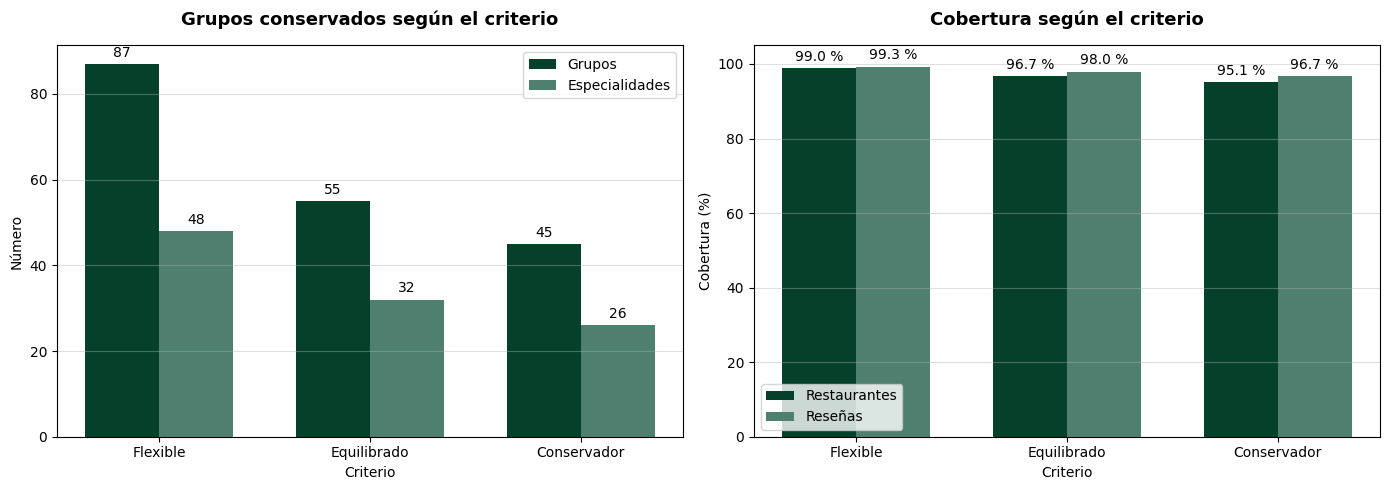

In [37]:
# Preparar la comparación de criterios
threshold_plot = threshold_comparison.reset_index()

x_positions = np.arange(len(threshold_plot))
bar_width = 0.35

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Número de grupos y especialidades
group_bars = axes[0].bar(
    x_positions - bar_width / 2,
    threshold_plot['eligible_groups'],
    width=bar_width,
    label='Grupos',
    color='#05402B'
)

specialty_bars = axes[0].bar(
    x_positions + bar_width / 2,
    threshold_plot['eligible_specialties'],
    width=bar_width,
    label='Especialidades',
    color='#4F7F6E'
)

axes[0].bar_label(group_bars, padding=3)
axes[0].bar_label(specialty_bars, padding=3)

axes[0].set_title(
    'Grupos conservados según el criterio',
    fontsize=13,
    fontweight='bold',
    pad=15
)
axes[0].set_xticks(
    x_positions,
    threshold_plot['criterion']
)
axes[0].set_xlabel('Criterio')
axes[0].set_ylabel('Número')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)

# Cobertura de restaurantes y reseñas
restaurant_bars = axes[1].bar(
    x_positions - bar_width / 2,
    threshold_plot[
        'restaurant_coverage_percentage'
    ],
    width=bar_width,
    label='Restaurantes',
    color='#05402B'
)

review_bars = axes[1].bar(
    x_positions + bar_width / 2,
    threshold_plot[
        'review_coverage_percentage'
    ],
    width=bar_width,
    label='Reseñas',
    color='#4F7F6E'
)

axes[1].bar_label(
    restaurant_bars,
    fmt='%.1f %%',
    padding=3
)
axes[1].bar_label(
    review_bars,
    fmt='%.1f %%',
    padding=3
)

axes[1].set_title(
    'Cobertura según el criterio',
    fontsize=13,
    fontweight='bold',
    pad=15
)
axes[1].set_xticks(
    x_positions,
    threshold_plot['criterion']
)
axes[1].set_xlabel('Criterio')
axes[1].set_ylabel('Cobertura (%)')
axes[1].set_ylim(0, 105)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()


plt.show()

In [38]:
# Materializar los grupos elegibles
# Umbral definitivo para el benchmarking
minimum_benchmark_restaurants = 30
minimum_benchmark_reviews = 1_000

eligible_benchmark_groups = (
    benchmark_group_support.loc[
        (
            benchmark_group_support['restaurants']
            >= minimum_benchmark_restaurants
        )
        & (
            benchmark_group_support['reviews']
            >= minimum_benchmark_reviews
        )
    ]
    .copy()
    .rename(
        columns={
            'restaurants': 'group_restaurants',
            'reviews': 'group_reviews'
        }
    )
)

# Crear un identificador legible del grupo
eligible_benchmark_groups['benchmark_group'] = (
    eligible_benchmark_groups['specialty']
    .astype('string')
    + ' | '
    + eligible_benchmark_groups['price_interval']
    .astype('string')
)

# Conservar las pertenencias a grupos elegibles
eligible_benchmark_membership = (
    benchmark_membership
    .merge(
        eligible_benchmark_groups[
            [
                'specialty',
                'price_interval',
                'benchmark_group',
                'group_restaurants',
                'group_reviews'
            ]
        ],
        on=[
            'specialty',
            'price_interval'
        ],
        how='inner',
        validate='many_to_one'
    )
)

selected_restaurant_ids = (
    eligible_benchmark_membership['item_id']
    .drop_duplicates()
)

selected_covered_reviews = (
    benchmark_restaurant_activity.loc[
        benchmark_restaurant_activity['item_id']
        .isin(selected_restaurant_ids),
        'reviews'
    ]
    .sum()
)

selected_benchmark_validation = pd.Series({
    'eligible_groups': len(eligible_benchmark_groups),
    'eligible_specialties': (
        eligible_benchmark_groups['specialty'].nunique()
    ),
    'covered_restaurants': (
        selected_restaurant_ids.nunique()
    ),
    'restaurant_coverage_percentage': (
        selected_restaurant_ids.nunique()
        / benchmark_total_restaurants
        * 100
    ),
    'covered_reviews': selected_covered_reviews,
    'review_coverage_percentage': (
        selected_covered_reviews
        / benchmark_total_reviews
        * 100
    )
}, name='result').to_frame()

selected_benchmark_validation.round(2)

,result
eligible_groups,55.00
eligible_specialties,32.00
covered_restaurants,6996.00
restaurant_coverage_percentage,96.74
covered_reviews,1098034.00
review_coverage_percentage,97.97


Se selecciona el criterio Equilibrado: al menos 30 restaurantes y 1,000 reseñas por especialidad y precio. Conserva 55 grupos, 32 especialidades, el 96.74 % de los restaurantes comparables y el 97.97 % de sus reseñas.

Los umbrales son reglas operativas de estabilidad. Un restaurante multietiqueta puede pertenecer a varios grupos.


## 4.7. Diagnóstico de la reputación a nivel de restaurante

El diagnóstico se construye mediante la agregación de las reseñas de cada
restaurante. Se consideran el volumen disponible, la valoración media, la
dispersión de las puntuaciones, la distribución del sentimiento y la cobertura
temporal.

Como `sentiment` se deriva de `review_rating`, ambas variables describen una
misma fuente de reputación y no deben interpretarse como indicadores
independientes.

### 4.7.1. Construcción de indicadores por restaurante

In [39]:
# Variables auxiliares para agregar el sentimiento
data['is_neutral'] = (
    data['sentiment']
    .eq('Neutral')
    .astype('int8')
)

data['is_positive'] = (
    data['sentiment']
    .eq('Positiva')
    .astype('int8')
)

# Construir una fila por restaurante
restaurant_reputation = (
    data
    .groupby(
        'item_id',
        as_index=False,
        observed=True
    )
    .agg(
        name=('name', 'first'),
        price_interval=('price_interval', 'first'),
        platform_rating=('restaurant_rating', 'first'),
        reviews=('review_id', 'size'),
        first_review_date=('date', 'min'),
        last_review_date=('date', 'max'),
        mean_review_rating=('review_rating', 'mean'),
        median_review_rating=('review_rating', 'median'),
        rating_std=('review_rating', 'std'),
        negative_reviews=('is_negative', 'sum'),
        neutral_reviews=('is_neutral', 'sum'),
        positive_reviews=('is_positive', 'sum')
    )
)

# Calcular indicadores porcentuales
restaurant_reputation['negative_percentage'] = (
    restaurant_reputation['negative_reviews']
    .div(restaurant_reputation['reviews'])
    .mul(100)
)

restaurant_reputation['neutral_percentage'] = (
    restaurant_reputation['neutral_reviews']
    .div(restaurant_reputation['reviews'])
    .mul(100)
)

restaurant_reputation['positive_percentage'] = (
    restaurant_reputation['positive_reviews']
    .div(restaurant_reputation['reviews'])
    .mul(100)
)

restaurant_reputation['review_span_days'] = (
    restaurant_reputation['last_review_date']
    - restaurant_reputation['first_review_date']
).dt.days

In [40]:
reputation_validation = pd.Series({
    'restaurants': len(restaurant_reputation),
    'unique_restaurants': (
        restaurant_reputation['item_id'].nunique()
    ),
    'total_reviews': (
        restaurant_reputation['reviews'].sum()
    ),
    'total_sentiment_assignments': (
        restaurant_reputation[
            [
                'negative_reviews',
                'neutral_reviews',
                'positive_reviews'
            ]
        ]
        .sum()
        .sum()
    ),
    'missing_mean_rating': (
        restaurant_reputation[
            'mean_review_rating'
        ]
        .isna()
        .sum()
    ),
    'restaurants_with_one_review': (
        restaurant_reputation['reviews']
        .eq(1)
        .sum()
    ),
    'missing_rating_std': (
        restaurant_reputation['rating_std']
        .isna()
        .sum()
    )
}, name='result').to_frame()

display(reputation_validation)

reputation_distribution = (
    restaurant_reputation[
        [
            'reviews',
            'mean_review_rating',
            'rating_std',
            'negative_percentage',
            'positive_percentage',
            'review_span_days'
        ]
    ]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .T
    .round(2)
)

reputation_distribution

,result
restaurants,10056
unique_restaurants,10056
total_reviews,1157800
total_sentiment_assignments,1157800
missing_mean_rating,0
restaurants_with_one_review,692
missing_rating_std,692


,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
reviews,10056.0,115.135243,411.042544,1.0,2.0,7.0,25.0,91.0,277.5,491.25,1295.15,22679.0
mean_review_rating,10056.0,3.817122,0.821724,1.0,2.736842,3.357143,3.954397,4.40253,4.833333,5.0,5.0,5.0
rating_std,9364.0,1.157799,0.478734,0.0,0.52182,0.915641,1.220851,1.461963,1.666799,1.82201,2.309401,2.828427
negative_percentage,10056.0,19.596903,21.096832,0.0,0.0,3.447176,13.636364,28.571429,50.0,62.092265,100.0,100.0
positive_percentage,10056.0,68.957983,25.352722,0.0,33.333333,52.941176,73.429705,88.888889,100.0,100.0,100.0,100.0
review_span_days,10056.0,1890.821897,1417.771178,0.0,92.5,651.0,1755.5,2879.0,3788.0,4398.5,5585.35,7514.0


La agregación es correcta. Los datos muestran una distribución muy asimétrica: la mediana es 25 reseñas, pero la media 115 y el máximo 22,679. Los 692 valores ausentes de rating_std corresponden exactamente a restaurantes con una sola reseña, por lo que no deben rellenarse con cero. Ahora clasificaremos el soporte del diagnóstico en cuatro niveles, sin eliminar restaurantes.

### 4.7.2. Nivel de soporte del diagnóstico

Los restaurantes se clasifican según el número de reseñas disponible. Esta
clasificación no elimina establecimientos: indica el volumen de evidencia disponible para sus indicadores.

In [41]:
# Definir niveles operativos de soporte
support_labels = [
    'Muy bajo (1-9)',
    'Bajo (10-29)',
    'Adecuado (30-99)',
    'Alto (100 o más)'
]

restaurant_reputation['diagnostic_support'] = pd.cut(
    restaurant_reputation['reviews'],
    bins=[
        0,
        9,
        29,
        99,
        np.inf
    ],
    labels=support_labels,
    include_lowest=True,
    ordered=True
)

# Resumir restaurantes y reseñas por nivel
diagnostic_support_summary = (
    restaurant_reputation
    .groupby(
        'diagnostic_support',
        observed=False
    )
    .agg(
        restaurants=('item_id', 'size'),
        reviews=('reviews', 'sum'),
        mean_reviews=('reviews', 'mean'),
        median_reviews=('reviews', 'median')
    )
)

diagnostic_support_summary[
    'restaurant_percentage'
] = (
    diagnostic_support_summary['restaurants']
    .div(diagnostic_support_summary['restaurants'].sum())
    .mul(100)
)

diagnostic_support_summary[
    'review_percentage'
] = (
    diagnostic_support_summary['reviews']
    .div(diagnostic_support_summary['reviews'].sum())
    .mul(100)
)

diagnostic_support_summary = (
    diagnostic_support_summary[
        [
            'restaurants',
            'restaurant_percentage',
            'reviews',
            'review_percentage',
            'mean_reviews',
            'median_reviews'
        ]
    ]
    .round(2)
)

display(diagnostic_support_summary)

print(
    'Total de restaurantes:',
    f"{diagnostic_support_summary['restaurants'].sum():,}"
)

print(
    'Total de reseñas:',
    f"{diagnostic_support_summary['reviews'].sum():,}"
)

,restaurants,restaurant_percentage,reviews,review_percentage,mean_reviews,median_reviews
diagnostic_support,,,,,,
Muy bajo (1-9),3062,30.45,12207,1.05,3.99,4.0
Bajo (10-29),2324,23.11,41679,3.60,17.93,17.0
Adecuado (30-99),2305,22.92,128836,11.13,55.89,52.0
Alto (100 o más),2365,23.52,975078,84.22,412.30,239.0


Total de restaurantes: 10,056
Total de reseñas: 1,157,800


### 4.7.3. Cobertura por nivel de soporte

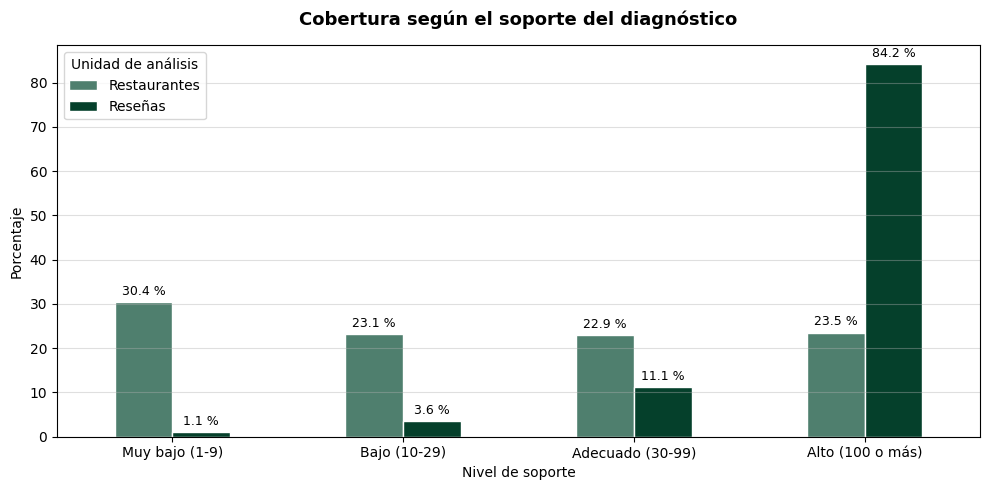

In [42]:
# Comparar cobertura de restaurantes y reseñas
diagnostic_support_plot = (
    diagnostic_support_summary[
        [
            'restaurant_percentage',
            'review_percentage'
        ]
    ]
    .rename(
        columns={
            'restaurant_percentage': 'Restaurantes',
            'review_percentage': 'Reseñas'
        }
    )
)

ax = diagnostic_support_plot.plot(
    kind='bar',
    figsize=(10, 5),
    color=['#4F7F6E', '#05402B'],
    edgecolor='white'
)

ax.set_title(
    'Cobertura según el soporte del diagnóstico',
    fontsize=13,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Nivel de soporte')
ax.set_ylabel('Porcentaje')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Unidad de análisis')
ax.grid(axis='y', alpha=0.4)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f %%',
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Asignar el estado definitivo**

In [43]:
# Estado operativo del diagnóstico
diagnostic_status_order = [
    'Datos insuficientes',
    'Diagnóstico limitado',
    'Diagnóstico completo'
]

restaurant_reputation['diagnostic_status'] = np.select(
    [
        restaurant_reputation['reviews'].ge(30),
        restaurant_reputation['reviews'].ge(10)
    ],
    [
        'Diagnóstico completo',
        'Diagnóstico limitado'
    ],
    default='Datos insuficientes'
)

restaurant_reputation['diagnostic_status'] = pd.Categorical(
    restaurant_reputation['diagnostic_status'],
    categories=diagnostic_status_order,
    ordered=True
)

diagnostic_status_summary = (
    restaurant_reputation
    .groupby(
        'diagnostic_status',
        observed=False
    )
    .agg(
        restaurants=('item_id', 'size'),
        reviews=('reviews', 'sum')
    )
)

diagnostic_status_summary['restaurant_percentage'] = (
    diagnostic_status_summary['restaurants']
    .div(len(restaurant_reputation))
    .mul(100)
)

diagnostic_status_summary['review_percentage'] = (
    diagnostic_status_summary['reviews']
    .div(restaurant_reputation['reviews'].sum())
    .mul(100)
)

diagnostic_status_summary.round(2)

,restaurants,reviews,restaurant_percentage,review_percentage
diagnostic_status,,,,
Datos insuficientes,3062,12207,30.45,1.05
Diagnóstico limitado,2324,41679,23.11,3.60
Diagnóstico completo,4670,1103914,46.44,95.35


Los restaurantes con menos de 30 reseñas representan el 53.56 % del catálogo, pero solo el 4.65 % de las reseñas.

El diagnóstico completo exige 30 reseñas: incluye 4,670 restaurantes y el 95.35 % de las reseñas. Entre 10 y 29 se muestra una advertencia; entre 1 y 9, `Datos insuficientes`.

Todas las reseñas se conservan para modelizar. La desviación no se imputa en los 692 restaurantes con una sola reseña.


### 4.7.4. Distribución reputacional de los restaurantes con diagnóstico completo

Se estudian los restaurantes con al menos 30 reseñas. Los resultados se
presentan como una descripción general del catálogo y no como criterios
globales para clasificar establecimientos como buenos o malos. Esa evaluación
se realizará posteriormente dentro de cada grupo competitivo.

In [44]:
# Seleccionar restaurantes con diagnóstico completo
complete_diagnosis = (
    restaurant_reputation.loc[
        restaurant_reputation[
            'diagnostic_status'
        ].eq('Diagnóstico completo')
    ]
    .copy()
)

# Validar la selección
complete_diagnosis_validation = pd.Series({
    'restaurants': len(complete_diagnosis),
    'unique_restaurants': (
        complete_diagnosis['item_id'].nunique()
    ),
    'reviews': (
        complete_diagnosis['reviews'].sum()
    ),
    'missing_rating_std': (
        complete_diagnosis['rating_std'].isna().sum()
    ),
    'minimum_reviews': (
        complete_diagnosis['reviews'].min()
    )
}, name='result').to_frame()

display(complete_diagnosis_validation)

,result
restaurants,4670
unique_restaurants,4670
reviews,1103914
missing_rating_std,0
minimum_reviews,30


In [45]:
complete_reputation_distribution = (
    complete_diagnosis[
        [
            'reviews',
            'mean_review_rating',
            'rating_std',
            'negative_percentage',
            'neutral_percentage',
            'positive_percentage',
            'review_span_days'
        ]
    ]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .T
    .round(2)
)

complete_reputation_distribution

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
reviews,4670.0,236.384154,579.93846,30.0,37.0,53.0,101.0,241.0,515.1,812.1,1971.09,22679.0
mean_review_rating,4670.0,3.84095,0.612562,1.383333,3.0,3.47619,3.922893,4.285714,4.558445,4.719372,4.885391,5.0
rating_std,4670.0,1.185175,0.282353,0.0,0.81874,1.011497,1.207468,1.392751,1.519703,1.591284,1.743205,1.971346
negative_percentage,4670.0,18.037966,14.707406,0.0,3.355122,7.246377,13.989247,24.675325,38.709677,49.232597,66.304462,90.0
neutral_percentage,4670.0,12.053513,7.156041,0.0,3.125,6.818182,11.315139,16.483516,21.570038,25.0,32.377583,46.153846
positive_percentage,4670.0,69.908521,18.728044,3.225806,42.857143,58.333333,73.333333,84.375,91.666667,94.829938,98.407221,100.0
review_span_days,4670.0,2848.213062,1251.745301,30.0,1244.9,1951.0,2826.0,3605.0,4450.8,5365.95,5644.0,7514.0


In [46]:
# Comparar métricas ponderadas y no ponderadas
# Comparar ambas perspectivas
reputation_weighting_summary = pd.Series({
    'restaurants': len(complete_diagnosis),
    'reviews': complete_diagnosis['reviews'].sum(),

    'unweighted_mean_rating': (
        complete_diagnosis[
            'mean_review_rating'
        ].mean()
    ),

    'review_weighted_mean_rating': np.average(
        complete_diagnosis[
            'mean_review_rating'
        ].astype(float),
        weights=complete_diagnosis['reviews']
    ),

    'unweighted_negative_percentage': (
        complete_diagnosis[
            'negative_percentage'
        ].mean()
    ),

    'review_weighted_negative_percentage': np.average(
        complete_diagnosis[
            'negative_percentage'
        ].astype(float),
        weights=complete_diagnosis['reviews']
    )
}, name='result').to_frame()

reputation_weighting_summary.round(2)

,result
restaurants,4670.00
reviews,1103914.00
unweighted_mean_rating,3.84
review_weighted_mean_rating,4.01
unweighted_negative_percentage,18.04
review_weighted_negative_percentage,13.47


### 4.7.5. Visualización de los indicadores reputacionales

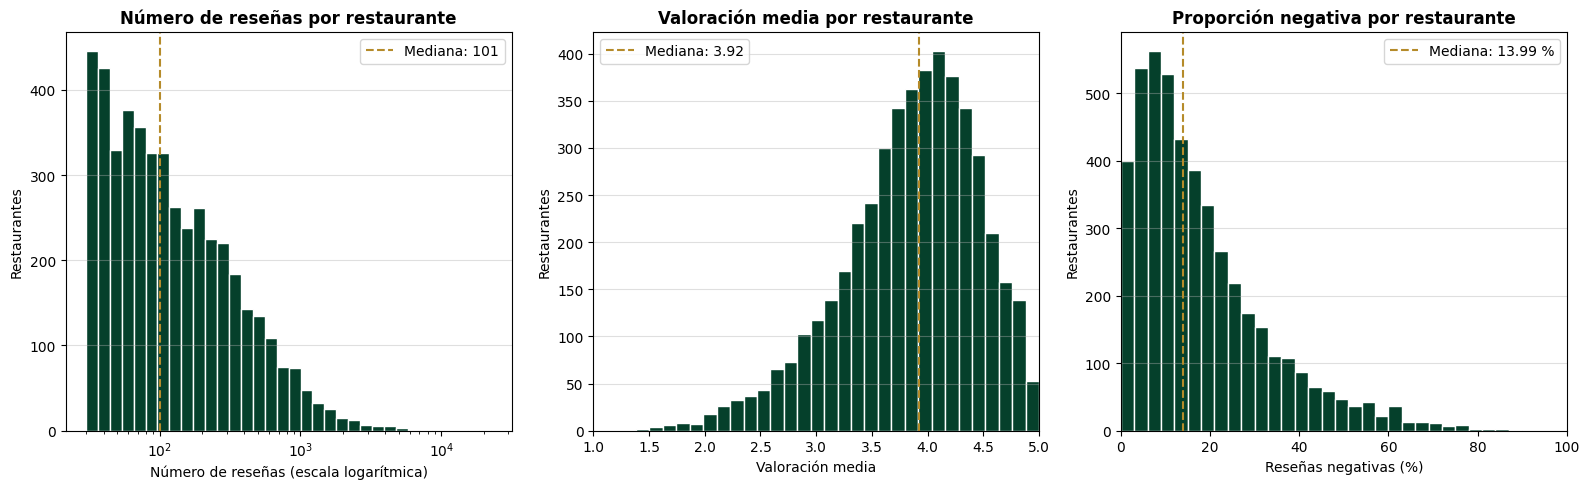

In [47]:
# Preparar intervalos logarítmicos para el volumen
review_bins = np.logspace(
    np.log10(complete_diagnosis['reviews'].min()),
    np.log10(complete_diagnosis['reviews'].max()),
    35
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5)
)

# Distribución del volumen
axes[0].hist(
    complete_diagnosis['reviews'],
    bins=review_bins,
    color='#05402B',
    edgecolor='white'
)

axes[0].axvline(
    complete_diagnosis['reviews'].median(),
    color='#B58B2A',
    linestyle='--',
    label=(
        'Mediana: '
        f"{complete_diagnosis['reviews'].median():.0f}"
    )
)

axes[0].set_xscale('log')
axes[0].set_title(
    'Número de reseñas por restaurante',
    fontweight='bold'
)
axes[0].set_xlabel(
    'Número de reseñas (escala logarítmica)'
)
axes[0].set_ylabel('Restaurantes')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)

# Distribución de la valoración media
axes[1].hist(
    complete_diagnosis['mean_review_rating'],
    bins=30,
    color='#05402B',
    edgecolor='white'
)

axes[1].axvline(
    complete_diagnosis[
        'mean_review_rating'
    ].median(),
    color='#B58B2A',
    linestyle='--',
    label=(
        'Mediana: '
        f"{complete_diagnosis['mean_review_rating'].median():.2f}"
    )
)

axes[1].set_title(
    'Valoración media por restaurante',
    fontweight='bold'
)
axes[1].set_xlabel('Valoración media')
axes[1].set_ylabel('Restaurantes')
axes[1].set_xlim(1, 5)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.4)

# Distribución de la proporción negativa
axes[2].hist(
    complete_diagnosis['negative_percentage'],
    bins=30,
    color='#05402B',
    edgecolor='white'
)

axes[2].axvline(
    complete_diagnosis[
        'negative_percentage'
    ].median(),
    color='#B58B2A',
    linestyle='--',
    label=(
        'Mediana: '
        f"{complete_diagnosis['negative_percentage'].median():.2f} %"
    )
)

axes[2].set_title(
    'Proporción negativa por restaurante',
    fontweight='bold'
)
axes[2].set_xlabel('Reseñas negativas (%)')
axes[2].set_ylabel('Restaurantes')
axes[2].set_xlim(0, 100)
axes[2].legend()
axes[2].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

En los 4,670 restaurantes con diagnóstico completo, la mediana es de 101 reseñas y la media 236.38, lo que confirma asimetría.

La valoración mediana es 3.92; la proporción negativa mediana, 13.99 %; la positiva, 73.33 %; y la desviación típica, 1.21. La mediana de cobertura histórica es 2,826 días.

Ponderadas por reseñas, la valoración es 4.01 y la proporción negativa 13.47 %. Sin ponderar son 3.84 y 18.04 %. Los restaurantes con más actividad muestran mejores indicadores, sin implicar causalidad.

El diagnóstico final compara restaurantes del mismo grupo competitivo, no percentiles globales.


### 4.7.6. Construcción de ventanas temporales para alerta reputacional

Para detectar cambios recientes en la reputación se comparan dos ventanas
consecutivas de seis meses completos:

- **Ventana anterior:** junio de 2022 a noviembre de 2022.
- **Ventana reciente:** diciembre de 2022 a mayo de 2023.

Junio de 2023 se excluye porque el dataset solamente contiene información hasta
el día 10 y, por tanto, no representa un mes completo.

Para cada restaurante se calcula el número de reseñas, la valoración media y la
proporción de reseñas negativas en cada ventana. Estas métricas permitirán
identificar posteriormente posibles señales de deterioro reputacional.

In [48]:
# Seleccionar variables temporales
temporal_data = data[
    [
        'review_id',
        'item_id',
        'date',
        'review_rating',
        'sentiment'
    ]
].copy()

# Crear un indicador de reseña negativa
temporal_data['is_negative'] = (
    temporal_data['sentiment']
    .eq('Negativa')
    .astype('int8')
)

# Identificar el último mes observado
last_observed_month = (
    temporal_data['date']
    .max()
    .to_period('M')
)

# Excluir el último mes porque está incompleto
last_complete_month = last_observed_month - 1

# Definir dos ventanas de seis meses
recent_start = (
    last_complete_month - 5
).to_timestamp()

recent_end = (
    last_complete_month + 1
).to_timestamp()

previous_start = (
    last_complete_month - 11
).to_timestamp()

previous_end = recent_start

print(
    'Ventana anterior:',
    previous_start.strftime('%Y-%m-%d'),
    'a',
    (previous_end - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
)

print(
    'Ventana reciente:',
    recent_start.strftime('%Y-%m-%d'),
    'a',
    (recent_end - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
)

Ventana anterior: 2022-06-01 a 2022-11-30
Ventana reciente: 2022-12-01 a 2023-05-31


In [49]:
# Seleccionar las reseñas de la ventana anterior
previous_window_reviews = temporal_data.loc[
    temporal_data['date'].ge(previous_start)
    & temporal_data['date'].lt(previous_end)
].copy()

# Seleccionar las reseñas de la ventana reciente
recent_window_reviews = temporal_data.loc[
    temporal_data['date'].ge(recent_start)
    & temporal_data['date'].lt(recent_end)
].copy()

In [50]:
# Resumir la actividad de la ventana anterior
previous_window_summary = (
    previous_window_reviews
    .groupby('item_id')
    .agg(
        previous_reviews=('review_id', 'size'),
        previous_negative_reviews=('is_negative', 'sum'),
        previous_mean_rating=('review_rating', 'mean'),
        previous_negative_percentage=(
            'is_negative',
            lambda series: series.mean() * 100
        )
    )
    .reset_index()
)

# Resumir la actividad de la ventana reciente
recent_window_summary = (
    recent_window_reviews
    .groupby('item_id')
    .agg(
        recent_reviews=('review_id', 'size'),
        recent_negative_reviews=('is_negative', 'sum'),
        recent_mean_rating=('review_rating', 'mean'),
        recent_negative_percentage=(
            'is_negative',
            lambda series: series.mean() * 100
        )
    )
    .reset_index()
)

In [51]:
# Integrar métricas temporales
restaurant_temporal_diagnosis = (
    restaurant_reputation
    .merge(
        previous_window_summary,
        on='item_id',
        how='left',
        validate='one_to_one'
    )
    .merge(
        recent_window_summary,
        on='item_id',
        how='left',
        validate='one_to_one'
    )
)

# Completar ventanas sin actividad
window_count_columns = [
    'previous_reviews',
    'previous_negative_reviews',
    'recent_reviews',
    'recent_negative_reviews'
]

restaurant_temporal_diagnosis[window_count_columns] = (
    restaurant_temporal_diagnosis[window_count_columns]
    .fillna(0)
    .astype('int64')
)

# Identificar restaurantes comparables
restaurant_temporal_diagnosis[
    'has_activity_both_windows'
] = (
    restaurant_temporal_diagnosis['previous_reviews'].gt(0)
    & restaurant_temporal_diagnosis['recent_reviews'].gt(0)
)

# Calcular los cambios entre las dos ventanas
restaurant_temporal_diagnosis['rating_change'] = (
    restaurant_temporal_diagnosis['recent_mean_rating']
    - restaurant_temporal_diagnosis['previous_mean_rating']
)

restaurant_temporal_diagnosis[
    'negative_percentage_point_change'
] = (
    restaurant_temporal_diagnosis['recent_negative_percentage']
    - restaurant_temporal_diagnosis['previous_negative_percentage']
)

In [52]:
# Validar las ventanas temporales
temporal_window_validation = pd.Series(
    {
        'previous_reviews': len(previous_window_reviews),
        'recent_reviews': len(recent_window_reviews),
        'previous_restaurants': (
            previous_window_reviews['item_id'].nunique()
        ),
        'recent_restaurants': (
            recent_window_reviews['item_id'].nunique()
        ),
        'restaurants_in_both_windows': (
            restaurant_temporal_diagnosis[
                'has_activity_both_windows'
            ].sum()
        ),
        'previous_negative_reviews': (
            previous_window_reviews['is_negative'].sum()
        ),
        'recent_negative_reviews': (
            recent_window_reviews['is_negative'].sum()
        )
    },
    name='result'
)

display(temporal_window_validation.to_frame())

,result
previous_reviews,35360
recent_reviews,38204
previous_restaurants,5068
recent_restaurants,5113
restaurants_in_both_windows,3762
previous_negative_reviews,5780
recent_negative_reviews,6147


In [53]:
# Examinar el soporte disponible en cada ventana
temporal_activity_distribution = (
    restaurant_temporal_diagnosis[
        [
            'previous_reviews',
            'recent_reviews'
        ]
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .T
    .round(2)
)

display(temporal_activity_distribution)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
previous_reviews,10056.0,3.52,18.18,0.0,0.0,1.0,2.0,6.0,12.0,45.00,622.0
recent_reviews,10056.0,3.80,20.14,0.0,0.0,1.0,2.0,7.0,12.0,44.45,587.0


### Conclusiones de las ventanas temporales

La ventana reciente contiene 38,204 reseñas y la anterior 35,360. Las negativas aumentan de 5,780 a 6,147, pero su proporción baja de 16.35 % a 16.09 %.

Hay 3,762 restaurantes activos en ambas ventanas. Como muchos tienen pocas reseñas, se exige soporte mínimo antes de emitir alertas.

Las métricas agregadas describen el mercado y no sustituyen el diagnóstico individual.


### 4.7.7. Sensibilidad del soporte temporal

Para evitar alertas basadas en variaciones poco estables, se comparan distintos
mínimos de reseñas por restaurante y ventana.

El análisis se limita a restaurantes que cuentan con diagnóstico histórico
completo —al menos 30 reseñas acumuladas— y presentan actividad en ambas
ventanas temporales.

Se evalúan mínimos de 3, 5, 10 y 20 reseñas en cada periodo. La decisión final
considerará tanto el número de restaurantes disponibles como la proporción de
reseñas conservada.

In [54]:
# Filtrar diagnóstico completo
# y actividad en ambas ventanas
temporal_candidates = (
    restaurant_temporal_diagnosis.loc[
        restaurant_temporal_diagnosis['reviews'].ge(30)
        & restaurant_temporal_diagnosis[
            'has_activity_both_windows'
        ]
    ]
    .copy()
)

candidate_restaurants = len(temporal_candidates)
candidate_previous_reviews = (
    temporal_candidates['previous_reviews'].sum()
)
candidate_recent_reviews = (
    temporal_candidates['recent_reviews'].sum()
)

temporal_candidate_summary = pd.Series(
    {
        'candidate_restaurants': candidate_restaurants,
        'previous_reviews': candidate_previous_reviews,
        'recent_reviews': candidate_recent_reviews,
        'previous_negative_reviews': (
            temporal_candidates[
                'previous_negative_reviews'
            ].sum()
        ),
        'recent_negative_reviews': (
            temporal_candidates[
                'recent_negative_reviews'
            ].sum()
        )
    },
    name='result'
)

display(temporal_candidate_summary.to_frame())

,result
candidate_restaurants,2814
previous_reviews,30663
recent_reviews,32014
previous_negative_reviews,4623
recent_negative_reviews,4873


In [55]:
# Evaluar mínimos por ventana
minimum_reviews_options = [3, 5, 10, 20]
temporal_sensitivity_results = []

for minimum_reviews in minimum_reviews_options:

    eligible_restaurants = temporal_candidates.loc[
        temporal_candidates[
            'previous_reviews'
        ].ge(minimum_reviews)
        & temporal_candidates[
            'recent_reviews'
        ].ge(minimum_reviews)
    ]

    eligible_count = len(eligible_restaurants)

    eligible_previous_reviews = (
        eligible_restaurants['previous_reviews'].sum()
    )

    eligible_recent_reviews = (
        eligible_restaurants['recent_reviews'].sum()
    )

    temporal_sensitivity_results.append(
        {
            'minimum_reviews_per_window': minimum_reviews,
            'eligible_restaurants': eligible_count,
            'restaurant_coverage_percentage': (
                eligible_count
                / candidate_restaurants
                * 100
            ),
            'previous_reviews': eligible_previous_reviews,
            'previous_review_coverage_percentage': (
                eligible_previous_reviews
                / candidate_previous_reviews
                * 100
            ),
            'recent_reviews': eligible_recent_reviews,
            'recent_review_coverage_percentage': (
                eligible_recent_reviews
                / candidate_recent_reviews
                * 100
            )
        }
    )

temporal_sensitivity = (
    pd.DataFrame(temporal_sensitivity_results)
    .set_index('minimum_reviews_per_window')
    .round(2)
)

display(temporal_sensitivity)

,eligible_restaurants,restaurant_coverage_percentage,previous_reviews,previous_review_coverage_percentage,recent_reviews,recent_review_coverage_percentage
minimum_reviews_per_window,,,,,,
3,1567,55.69,27918,91.05,29038,90.70
5,1017,36.14,25351,82.68,26140,81.65
10,450,15.99,20480,66.79,21309,66.56
20,178,6.33,15914,51.90,16528,51.63


#### Conclusiones de la sensibilidad del soporte temporal

Tres reseñas por ventana ofrecen 55.69 % de cobertura, pero una sola observación cambia 33.33 puntos porcentuales.

Se eligen cinco reseñas: conserva 1,017 restaurantes y alrededor del 82 % de las reseñas de cada ventana. Diez reduce la muestra a 450 y veinte a 178.

De 5 a 9 reseñas el soporte es moderado; con 10 o más es superior. La alerta indica deterioro observado, no una predicción causal.


### 4.7.8. Selección de la muestra para la alerta reputacional

Se seleccionan los restaurantes con al menos cinco reseñas en cada ventana.
Posteriormente se asigna un nivel de soporte según el menor número de reseñas
disponible entre ambos periodos:

- **Moderado:** entre 5 y 9 reseñas.
- **Alto:** entre 10 y 19 reseñas.
- **Muy alto:** 20 o más reseñas.

El nivel de soporte permitirá diferenciar las señales preliminares de aquellas
basadas en un mayor volumen de información.

In [56]:
# Establecer el soporte temporal mínimo
minimum_temporal_reviews = 5

# Filtrar alertas evaluables
temporal_alert_base = (
    temporal_candidates.loc[
        temporal_candidates[
            'previous_reviews'
        ].ge(minimum_temporal_reviews)
        & temporal_candidates[
            'recent_reviews'
        ].ge(minimum_temporal_reviews)
    ]
    .copy()
)

# Obtener el menor soporte entre las dos ventanas
temporal_alert_base[
    'minimum_window_reviews'
] = (
    temporal_alert_base[
        [
            'previous_reviews',
            'recent_reviews'
        ]
    ]
    .min(axis=1)
)

# Clasificar el nivel de soporte temporal
temporal_alert_base['temporal_support_level'] = pd.cut(
    temporal_alert_base['minimum_window_reviews'],
    bins=[4, 9, 19, np.inf],
    labels=[
        'Moderado (5-9)',
        'Alto (10-19)',
        'Muy alto (20 o más)'
    ],
    ordered=True
)

In [57]:
# Validar la muestra seleccionada
temporal_alert_validation = pd.Series(
    {
        'eligible_restaurants': len(temporal_alert_base),
        'unique_restaurants': (
            temporal_alert_base['item_id'].nunique()
        ),
        'previous_reviews': (
            temporal_alert_base['previous_reviews'].sum()
        ),
        'recent_reviews': (
            temporal_alert_base['recent_reviews'].sum()
        ),
        'missing_rating_change': (
            temporal_alert_base['rating_change'].isna().sum()
        ),
        'missing_negative_change': (
            temporal_alert_base[
                'negative_percentage_point_change'
            ].isna().sum()
        )
    },
    name='result'
)

display(temporal_alert_validation.to_frame())

,result
eligible_restaurants,1017
unique_restaurants,1017
previous_reviews,25351
recent_reviews,26140
missing_rating_change,0
missing_negative_change,0


In [58]:
# Resumir la muestra por nivel de soporte
temporal_support_summary = (
    temporal_alert_base
    .groupby(
        'temporal_support_level',
        observed=True
    )
    .agg(
        restaurants=('item_id', 'nunique'),
        previous_reviews=('previous_reviews', 'sum'),
        recent_reviews=('recent_reviews', 'sum')
    )
)

temporal_support_summary[
    'restaurant_percentage'
] = (
    temporal_support_summary['restaurants']
    .div(temporal_support_summary['restaurants'].sum())
    .mul(100)
)

temporal_support_summary = temporal_support_summary[
    [
        'restaurants',
        'restaurant_percentage',
        'previous_reviews',
        'recent_reviews'
    ]
].round(2)

display(temporal_support_summary)

,restaurants,restaurant_percentage,previous_reviews,recent_reviews
temporal_support_level,,,,
Moderado (5-9),567,55.75,4871,4831
Alto (10-19),272,26.75,4566,4781
Muy alto (20 o más),178,17.50,15914,16528


In [59]:
# Resumir cambios reputacionales
temporal_change_distribution = (
    temporal_alert_base[
        [
            'rating_change',
            'negative_percentage_point_change'
        ]
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .T
    .round(2)
)

display(temporal_change_distribution)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
rating_change,1017.0,-0.024795,0.675912,-2.333333,-1.662857,-1.093074,-0.836364,-0.397727,-0.038278,0.309091,0.817027,1.183654,1.893801,3.388889
negative_percentage_point_change,1017.0,0.28022,19.145192,-88.888889,-54.199134,-33.333333,-22.222222,-8.571429,0.0,10.0,22.945055,30.977273,50.0,83.333333


#### Conclusiones de la muestra temporal

La muestra contiene 1,017 restaurantes y 51,491 reseñas. El 55.75 % tiene soporte moderado y el 44.25 % al menos 10 reseñas por ventana.

La variación mediana de valoración es −0.04 y la del porcentaje negativo es cero. El cuartil con mayor deterioro cae al menos 0.40 puntos y sube 10 puntos porcentuales negativos; el decil más desfavorable cae 0.84 y sube 22.95.

Las dos métricas derivan de `review_rating` y no son evidencias independientes.


### 4.7.9. Construcción de la alerta reputacional

La alerta exige simultáneamente:

- **Vigilancia:** valoración ≤ −0.40 y negativas ≥ +10 puntos porcentuales.
- **Alerta alta:** valoración ≤ −0.80 y negativas ≥ +20.
- **Alerta crítica:** valoración ≤ −1.00 y negativas ≥ +30.

Los umbrales son reglas operativas de priorización. Describen cambios observados y no predicen causas ni evolución futura.


In [60]:
# Definir las condiciones de deterioro reputacional
critical_alert_condition = (
    temporal_alert_base['rating_change'].le(-1.00)
    & temporal_alert_base[
        'negative_percentage_point_change'
    ].ge(30.00)
)

high_alert_condition = (
    temporal_alert_base['rating_change'].le(-0.80)
    & temporal_alert_base[
        'negative_percentage_point_change'
    ].ge(20.00)
)

watch_condition = (
    temporal_alert_base['rating_change'].le(-0.40)
    & temporal_alert_base[
        'negative_percentage_point_change'
    ].ge(10.00)
)

# Asignar primero las categorías más graves
temporal_alert_base['alert_level'] = np.select(
    [
        critical_alert_condition,
        high_alert_condition,
        watch_condition
    ],
    [
        'Alerta crítica',
        'Alerta alta',
        'Vigilancia'
    ],
    default='Sin alerta'
)

# Establecer un orden lógico
alert_order = [
    'Sin alerta',
    'Vigilancia',
    'Alerta alta',
    'Alerta crítica'
]

temporal_alert_base['alert_level'] = pd.Categorical(
    temporal_alert_base['alert_level'],
    categories=alert_order,
    ordered=True
)

In [61]:
# Resumir los niveles de alerta
alert_summary = (
    temporal_alert_base['alert_level']
    .value_counts(sort=False)
    .reindex(alert_order, fill_value=0)
    .rename_axis('alert_level')
    .to_frame('restaurants')
)

alert_summary['restaurant_percentage'] = (
    alert_summary['restaurants']
    .div(alert_summary['restaurants'].sum())
    .mul(100)
    .round(2)
)

display(alert_summary)

print(
    'Restaurantes evaluados:',
    f'{len(temporal_alert_base):,}'
)

print(
    'Restaurantes con alguna señal:',
    f"{alert_summary.loc[
        ['Vigilancia', 'Alerta alta', 'Alerta crítica'],
        'restaurants'
    ].sum():,}"
)

,restaurants,restaurant_percentage
alert_level,,
Sin alerta,818,80.43
Vigilancia,114,11.21
Alerta alta,40,3.93
Alerta crítica,45,4.42


Restaurantes evaluados: 1,017
Restaurantes con alguna señal: 199


In [62]:
# Comparar alerta y soporte
alert_support_table = pd.crosstab(
    temporal_alert_base['alert_level'],
    temporal_alert_base['temporal_support_level'],
    margins=True,
    margins_name='Total'
)

display(alert_support_table)

temporal_support_level,Moderado (5-9),Alto (10-19),Muy alto (20 o más),Total
alert_level,,,,
Sin alerta,434,218,166,818
Vigilancia,75,34,5,114
Alerta alta,23,13,4,40
Alerta crítica,35,7,3,45
Total,567,272,178,1017


In [63]:
# Seleccionar restaurantes con señales de deterioro
restaurant_alerts = (
    temporal_alert_base.loc[
        temporal_alert_base['alert_level'].ne('Sin alerta'),
        [
            'item_id',
            'name',
            'price_interval',
            'previous_reviews',
            'recent_reviews',
            'minimum_window_reviews',
            'previous_mean_rating',
            'recent_mean_rating',
            'rating_change',
            'previous_negative_percentage',
            'recent_negative_percentage',
            'negative_percentage_point_change',
            'temporal_support_level',
            'alert_level'
        ]
    ]
    .sort_values(
        by=[
            'alert_level',
            'minimum_window_reviews',
            'rating_change'
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
)

display(restaurant_alerts.head(20).round(2))

,item_id,name,price_interval,previous_reviews,recent_reviews,minimum_window_reviews,previous_mean_rating,recent_mean_rating,rating_change,previous_negative_percentage,recent_negative_percentage,negative_percentage_point_change,temporal_support_level,alert_level
1543,12858177,Ramses Madrid,Premium,56,22,22,4.41,3.32,-1.09,10.71,40.91,30.19,Muy alto (20 o más),Alerta crítica
8913,796535,La Cabana Argentina,Moderado,33,21,21,4.64,3.62,-1.02,0.00,33.33,33.33,Muy alto (20 o más),Alerta crítica
9308,8624158,Txapela,Moderado,60,20,20,4.35,2.8,-1.55,15.00,55.00,40.00,Muy alto (20 o más),Alerta crítica
8917,797208,Viridiana,Premium,39,17,17,4.82,3.41,-1.41,5.13,35.29,30.17,Alto (10-19),Alerta crítica
3665,1829992,El Tigre,Económico,16,16,16,3.88,2.75,-1.12,18.75,50.00,31.25,Alto (10-19),Alerta crítica
336,10472330,Casa Carmen Arturo Soria,Moderado,12,20,12,3.42,1.8,-1.62,41.67,85.00,43.33,Alto (10-19),Alerta crítica
8299,6922754,Hattori Hanzo,Moderado,12,13,12,3.83,2.77,-1.06,16.67,61.54,44.87,Alto (10-19),Alerta crítica
1626,12912040,Santerra Restaurante,Premium,11,14,11,4.64,3.43,-1.21,0.00,35.71,35.71,Alto (10-19),Alerta crítica
7495,5493060,El Gran Barril,Premium,10,13,10,4.0,2.54,-1.46,10.00,61.54,51.54,Alto (10-19),Alerta crítica
9536,921496,La Sirena Verde,Moderado,17,10,10,3.53,2.2,-1.33,29.41,70.00,40.59,Alto (10-19),Alerta crítica


#### Conclusiones de la alerta reputacional

De 1,017 restaurantes, 818 (80.43 %) no activan alerta y 199 (19.57 %) muestran deterioro: 114 en vigilancia, 40 en alerta alta y 45 en alerta crítica.

De las 199 señales, 133 tienen soporte moderado; 35 de las 45 alertas críticas pertenecen a este grupo. Deben validarse con nuevas reseñas.

Las 66 señales con al menos 10 reseñas por ventana tienen mayor soporte. Gravedad y soporte se mantienen separados.


### 4.7.10. Priorización operativa de las alertas

- **Atención prioritaria:** alerta crítica y al menos 10 reseñas por ventana.
- **Revisión prioritaria:** alerta alta y al menos 10.
- **Seguimiento:** vigilancia y al menos 10.
- **Validar con más información:** cualquier señal con 5 a 9.
- **Sin acción inmediata:** sin alerta.

La prioridad combina gravedad y soporte.


In [64]:
# Filtrar mayor soporte
higher_support_condition = (
    temporal_alert_base['minimum_window_reviews'].ge(10)
)

# Asignar prioridad operativa
temporal_alert_base['operational_priority'] = np.select(
    [
        temporal_alert_base['alert_level'].eq(
            'Alerta crítica'
        )
        & higher_support_condition,

        temporal_alert_base['alert_level'].eq(
            'Alerta alta'
        )
        & higher_support_condition,

        temporal_alert_base['alert_level'].eq(
            'Vigilancia'
        )
        & higher_support_condition,

        temporal_alert_base['alert_level'].ne(
            'Sin alerta'
        )
        & ~higher_support_condition
    ],
    [
        'Atención prioritaria',
        'Revisión prioritaria',
        'Seguimiento',
        'Validar con más información'
    ],
    default='Sin acción inmediata'
)

# Establecer el orden de prioridad
priority_order = [
    'Sin acción inmediata',
    'Validar con más información',
    'Seguimiento',
    'Revisión prioritaria',
    'Atención prioritaria'
]

temporal_alert_base['operational_priority'] = (
    pd.Categorical(
        temporal_alert_base['operational_priority'],
        categories=priority_order,
        ordered=True
    )
)

In [65]:
# Resumir la prioridad operativa
operational_priority_summary = (
    temporal_alert_base['operational_priority']
    .value_counts(sort=False)
    .reindex(priority_order, fill_value=0)
    .rename_axis('operational_priority')
    .to_frame('restaurants')
)

operational_priority_summary[
    'restaurant_percentage'
] = (
    operational_priority_summary['restaurants']
    .div(operational_priority_summary['restaurants'].sum())
    .mul(100)
    .round(2)
)

display(operational_priority_summary)

,restaurants,restaurant_percentage
operational_priority,,
Sin acción inmediata,818,80.43
Validar con más información,133,13.08
Seguimiento,39,3.83
Revisión prioritaria,17,1.67
Atención prioritaria,10,0.98


In [66]:
# Crear tabla de alertas
operational_alerts = (
    temporal_alert_base.loc[
        temporal_alert_base[
            'operational_priority'
        ].ne('Sin acción inmediata'),
        [
            'item_id',
            'name',
            'price_interval',
            'previous_reviews',
            'recent_reviews',
            'minimum_window_reviews',
            'previous_mean_rating',
            'recent_mean_rating',
            'rating_change',
            'previous_negative_percentage',
            'recent_negative_percentage',
            'negative_percentage_point_change',
            'temporal_support_level',
            'alert_level',
            'operational_priority'
        ]
    ]
    .sort_values(
        by=[
            'operational_priority',
            'minimum_window_reviews',
            'rating_change'
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

display(operational_alerts.head(20).round(2))

,item_id,name,price_interval,previous_reviews,recent_reviews,minimum_window_reviews,previous_mean_rating,recent_mean_rating,rating_change,previous_negative_percentage,recent_negative_percentage,negative_percentage_point_change,temporal_support_level,alert_level,operational_priority
0,12858177,Ramses Madrid,Premium,56,22,22,4.41,3.32,-1.09,10.71,40.91,30.19,Muy alto (20 o más),Alerta crítica,Atención prioritaria
1,796535,La Cabana Argentina,Moderado,33,21,21,4.64,3.62,-1.02,0.00,33.33,33.33,Muy alto (20 o más),Alerta crítica,Atención prioritaria
2,8624158,Txapela,Moderado,60,20,20,4.35,2.8,-1.55,15.00,55.00,40.00,Muy alto (20 o más),Alerta crítica,Atención prioritaria
3,797208,Viridiana,Premium,39,17,17,4.82,3.41,-1.41,5.13,35.29,30.17,Alto (10-19),Alerta crítica,Atención prioritaria
4,1829992,El Tigre,Económico,16,16,16,3.88,2.75,-1.12,18.75,50.00,31.25,Alto (10-19),Alerta crítica,Atención prioritaria
5,10472330,Casa Carmen Arturo Soria,Moderado,12,20,12,3.42,1.8,-1.62,41.67,85.00,43.33,Alto (10-19),Alerta crítica,Atención prioritaria
6,6922754,Hattori Hanzo,Moderado,12,13,12,3.83,2.77,-1.06,16.67,61.54,44.87,Alto (10-19),Alerta crítica,Atención prioritaria
7,12912040,Santerra Restaurante,Premium,11,14,11,4.64,3.43,-1.21,0.00,35.71,35.71,Alto (10-19),Alerta crítica,Atención prioritaria
8,5493060,El Gran Barril,Premium,10,13,10,4.0,2.54,-1.46,10.00,61.54,51.54,Alto (10-19),Alerta crítica,Atención prioritaria
9,921496,La Sirena Verde,Moderado,17,10,10,3.53,2.2,-1.33,29.41,70.00,40.59,Alto (10-19),Alerta crítica,Atención prioritaria


#### Conclusiones de la priorización operativa

El monitoreo temporal puede aplicarse a 1,017 de los 10,056 restaurantes
(10.11 %), porque exige al menos cinco reseñas en cada ventana. Los 9,039
restantes (89.89 %) se clasifican como **Sin datos temporales suficientes**;
esta condición no representa una alerta ni un deterioro reputacional.

Entre los restaurantes evaluables, 818 (80.43 %) no requieren acción inmediata
y 199 (19.57 %) presentan alguna señal. La priorización identifica 10
restaurantes para atención prioritaria, 17 para revisión prioritaria, 39 para
seguimiento y 133 que deben validarse con más información por su soporte
moderado.

La priorización combina la magnitud del cambio, el soporte disponible y la
acción recomendada. Los restaurantes sin información de precio participan en
el monitoreo temporal, pero no en las comparaciones por rango de precio.


## 4.8. Conclusiones integradas del análisis exploratorio

- Se analizaron 1,157,800 reseñas de 10,056 restaurantes.
- La clase positiva representa el 74.71 %; se priorizan macro F1, recall negativo y balanced accuracy, con pesos de clase.
- El corpus bilingüe contiene 82.8 % de español y 17.2 % de inglés; se entrena un modelo único y se evalúa por idioma.
- La alerta usa dos ventanas completas de seis meses: 1,017 restaurantes son evaluables, 199 muestran señal y 10 requieren atención prioritaria.
- El precio conocido cubre el 98.04 % de las reseñas y solo se usa para benchmarking.
- El criterio de 30 restaurantes y 1,000 reseñas produce 55 grupos de 32 especialidades.
- El diagnóstico completo incluye 4,670 restaurantes y el 95.35 % de las reseñas.
- El clasificador utiliza solo `title` y `text`; puntuaciones y agregados se excluyen para evitar fuga de información.


# 5. Preparación del corpus para la modelización

Esta sección construye el corpus definitivo que se utilizará en el Notebook 3.
La preparación mantiene únicamente las variables necesarias para entrenar,
dividir y evaluar el clasificador de sentimiento.

No se aplicará todavía TF-IDF, normalización lingüística ni entrenamiento. Estas
transformaciones se ajustarán exclusivamente con los datos de entrenamiento
para evitar fuga de información.

## 5.1. Construcción del texto de modelización

El título y el contenido de cada reseña se combinan en una única variable
denominada `review_text`. Se conservan mayúsculas, acentos, puntuación y demás
elementos del texto original para permitir diferentes estrategias de NLP.

Las variables utilizadas serán:

- `review_id`: trazabilidad de la reseña.
- `item_id`: agrupación por restaurante durante la división.
- `date`: evaluación temporal.
- `language`: evaluación segmentada por idioma.
- `review_text`: única variable predictora.
- `sentiment`: variable objetivo.

`review_rating`, `restaurant_rating`, el precio y las métricas reputacionales
no se incluyen como predictores para evitar fuga de información.

In [67]:
# Seleccionar las variables necesarias
modeling_corpus = data[
    [
        'review_id',
        'item_id',
        'date',
        'language',
        'title',
        'text',
        'sentiment'
    ]
].copy()

# Normalizar solamente espacios y valores ausentes
modeling_corpus['title'] = (
    modeling_corpus['title']
    .astype('string')
    .fillna('')
    .str.strip()
)

modeling_corpus['text'] = (
    modeling_corpus['text']
    .astype('string')
    .fillna('')
    .str.strip()
)

# Combinar título y contenido
modeling_corpus['review_text'] = np.where(
    modeling_corpus['title'].eq(''),
    modeling_corpus['text'],
    np.where(
        modeling_corpus['text'].eq(''),
        modeling_corpus['title'],
        modeling_corpus['title']
        + '. '
        + modeling_corpus['text']
    )
)

modeling_corpus['review_text'] = (
    modeling_corpus['review_text']
    .astype('string')
    .str.strip()
)

# Conservar únicamente las variables finales
modeling_corpus = modeling_corpus[
    [
        'review_id',
        'item_id',
        'date',
        'language',
        'review_text',
        'sentiment'
    ]
].copy()

## 5.2. Validación del corpus

In [68]:
# Validar la estructura del corpus de modelización
modeling_corpus_validation = pd.Series(
    {
        'rows': len(modeling_corpus),
        'unique_review_ids': (
            modeling_corpus['review_id'].nunique()
        ),
        'unique_restaurants': (
            modeling_corpus['item_id'].nunique()
        ),
        'duplicated_review_ids': (
            modeling_corpus['review_id'].duplicated().sum()
        ),
        'missing_review_text': (
            modeling_corpus['review_text'].isna().sum()
        ),
        'empty_review_text': (
            modeling_corpus['review_text'].eq('').sum()
        ),
        'missing_sentiment': (
            modeling_corpus['sentiment'].isna().sum()
        ),
        'missing_language': (
            modeling_corpus['language'].isna().sum()
        ),
        'missing_dates': (
            modeling_corpus['date'].isna().sum()
        )
    },
    name='result'
)

display(modeling_corpus_validation.to_frame())

,result
rows,1157800
unique_review_ids,1157800
unique_restaurants,10056
duplicated_review_ids,0
missing_review_text,0
empty_review_text,0
missing_sentiment,0
missing_language,0
missing_dates,0


### Conclusiones de la validación del corpus

El corpus definitivo contiene 1,157,800 reseñas pertenecientes a 10,056
restaurantes. Cada reseña conserva un identificador único y no existen textos
vacíos, valores ausentes ni duplicados de `review_id`.

El corpus se encuentra preparado para realizar una división reproducible antes
de ajustar cualquier transformación textual. El preprocesamiento NLP se
aplicará posteriormente dentro de los pipelines de modelización.

## 5.3. División estratificada y agrupada del corpus

El corpus se divide aproximadamente en 80 % para entrenamiento, 10 % para
validación y 10 % para prueba.

La división se estratifica por sentimiento y se agrupa mediante `item_id`. De
esta manera, todas las reseñas de un restaurante pertenecen exclusivamente a
una partición, evitando que el modelo aprenda características particulares de
un establecimiento y las encuentre nuevamente durante la evaluación.

La partición de prueba permanecerá aislada hasta seleccionar el modelo final.
TF-IDF y cualquier otra transformación textual se ajustarán únicamente con el
conjunto de entrenamiento.

In [69]:
from sklearn.model_selection import StratifiedGroupKFold


# Preparar la división
split_target = modeling_corpus['sentiment'].to_numpy()
split_groups = modeling_corpus['item_id'].to_numpy()
dummy_features = np.zeros(
    len(modeling_corpus),
    dtype='int8'
)

# Separar aproximadamente el 10 % para prueba
test_splitter = StratifiedGroupKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

development_indices, test_indices = next(
    test_splitter.split(
        dummy_features,
        split_target,
        groups=split_groups
    )
)

# Dividir entrenamiento y validación
validation_splitter = StratifiedGroupKFold(
    n_splits=9,
    shuffle=True,
    random_state=43
)

train_relative_indices, validation_relative_indices = next(
    validation_splitter.split(
        dummy_features[development_indices],
        split_target[development_indices],
        groups=split_groups[development_indices]
    )
)

# Recuperar índices completos
train_indices = development_indices[
    train_relative_indices
]

validation_indices = development_indices[
    validation_relative_indices
]

# Asignar una etiqueta a cada observación
split_labels = np.full(
    len(modeling_corpus),
    '',
    dtype=object
)

split_labels[train_indices] = 'train'
split_labels[validation_indices] = 'validation'
split_labels[test_indices] = 'test'

split_order = [
    'train',
    'validation',
    'test'
]

modeling_corpus['dataset_split'] = pd.Categorical(
    split_labels,
    categories=split_order,
    ordered=True
)

In [70]:
# Resumir el tamaño de cada partición
split_summary = (
    modeling_corpus
    .groupby('dataset_split', observed=True)
    .agg(
        reviews=('review_id', 'size'),
        restaurants=('item_id', 'nunique')
    )
    .reindex(split_order)
)

split_summary['review_percentage'] = (
    split_summary['reviews']
    .div(split_summary['reviews'].sum())
    .mul(100)
)

split_summary['restaurant_percentage'] = (
    split_summary['restaurants']
    .div(split_summary['restaurants'].sum())
    .mul(100)
)

split_summary = split_summary[
    [
        'reviews',
        'review_percentage',
        'restaurants',
        'restaurant_percentage'
    ]
].round(2)

display(split_summary)

,reviews,review_percentage,restaurants,restaurant_percentage
dataset_split,,,,
train,931880,80.49,8025,79.80
validation,115008,9.93,1035,10.29
test,110912,9.58,996,9.90


In [71]:
# Obtener los restaurantes de cada partición
train_restaurants = set(
    modeling_corpus.loc[
        modeling_corpus['dataset_split'].eq('train'),
        'item_id'
    ]
)

validation_restaurants = set(
    modeling_corpus.loc[
        modeling_corpus['dataset_split'].eq('validation'),
        'item_id'
    ]
)

test_restaurants = set(
    modeling_corpus.loc[
        modeling_corpus['dataset_split'].eq('test'),
        'item_id'
    ]
)

# Validar que no existan restaurantes compartidos
split_validation = pd.Series(
    {
        'unassigned_reviews': (
            modeling_corpus['dataset_split'].isna().sum()
        ),
        'train_validation_overlap': len(
            train_restaurants & validation_restaurants
        ),
        'train_test_overlap': len(
            train_restaurants & test_restaurants
        ),
        'validation_test_overlap': len(
            validation_restaurants & test_restaurants
        )
    },
    name='result'
)

display(split_validation.to_frame())

,result
unassigned_reviews,0
train_validation_overlap,0
train_test_overlap,0
validation_test_overlap,0


In [72]:
# Comparar la distribución del sentimiento
split_sentiment_percentage = (
    pd.crosstab(
        modeling_corpus['dataset_split'],
        modeling_corpus['sentiment'],
        normalize='index'
    )
    .mul(100)
    .reindex(
        index=split_order,
        columns=sentiment_order
    )
    .round(2)
)

display(split_sentiment_percentage)

sentiment,Negativa,Neutral,Positiva
dataset_split,,,
train,13.92,11.57,74.51
validation,13.33,10.98,75.69
test,13.65,10.96,75.39


### Conclusiones de la división del corpus

La división contiene 931,880 reseñas de entrenamiento, 115,008 de validación y 110,912 de prueba: 80.49 %, 9.93 % y 9.58 %.

Incluye 8,025, 1,035 y 996 restaurantes sin solapamiento. La distribución del sentimiento se mantiene estable.

Las diferencias frente a 80/10/10 se deben a que cada restaurante pertenece a una sola partición. Las semillas fijan la reproducción.


## 5.4. Persistencia del corpus de modelización

El corpus y su partición se guardan en Parquet con compresión. El formato conserva tipos, permite lectura eficiente y facilita una migración a Spark o BigQuery.


In [73]:
import pyarrow.parquet as pq


# Definir la ruta del corpus de modelización
modeling_corpus_path = (
    DATA_PATH / 'modeling_corpus.parquet'
)

# Guardar el corpus con compresión
modeling_corpus.to_parquet(
    modeling_corpus_path,
    index=False,
    engine='pyarrow',
    compression='snappy'
)

In [74]:
# Leer metadatos
parquet_file = pq.ParquetFile(
    modeling_corpus_path
)

export_validation = pd.Series(
    {
        'file': modeling_corpus_path.name,
        'exists': modeling_corpus_path.exists(),
        'rows': parquet_file.metadata.num_rows,
        'columns': len(parquet_file.schema_arrow.names),
        'row_groups': parquet_file.metadata.num_row_groups,
        'size_mb': (
            modeling_corpus_path.stat().st_size
            / 1024 ** 2
        )
    },
    name='result'
).to_frame()

display(export_validation.round(2))

,result
file,modeling_corpus.parquet
exists,True
rows,1157800
columns,7
row_groups,2
size_mb,272.712769


### Conclusiones de la persistencia del corpus

El archivo Parquet contiene 1,157,800 reseñas, siete variables y la partición reproducible. Ocupa 272.71 MB y es compatible con Pandas, Spark y BigQuery.


## 5.5. Persistencia de los productos analíticos

Además del corpus de modelización, se almacenan los resultados analíticos a
nivel de restaurante:

- diagnóstico histórico de reputación;
- diagnóstico temporal y nivel de alerta;
- pertenencia a grupos competitivos elegibles;
- soporte de cada grupo competitivo.

Estos archivos separan el procesamiento analítico de la futura capa de
visualización y permiten que la aplicación consulte resultados previamente
calculados.

In [75]:
# Eliminar membresías duplicadas
benchmark_membership_export = (
    benchmark_membership[
        [
            'item_id',
            'specialty',
            'price_interval'
        ]
    ]
    .drop_duplicates()
    .merge(
        restaurant_reputation[
            [
                'item_id',
                'reviews'
            ]
        ],
        on='item_id',
        how='left',
        validate='many_to_one'
    )
)

# Calcular el soporte de cada grupo competitivo
benchmark_group_support_export = (
    benchmark_membership_export
    .groupby(
        [
            'specialty',
            'price_interval'
        ],
        observed=True
    )
    .agg(
        restaurants=('item_id', 'nunique'),
        reviews=('reviews', 'sum')
    )
    .reset_index()
)

# Aplicar el criterio equilibrado seleccionado
eligible_benchmark_groups_export = (
    benchmark_group_support_export.loc[
        benchmark_group_support_export[
            'restaurants'
        ].ge(30)
        & benchmark_group_support_export[
            'reviews'
        ].ge(1_000)
    ]
    .copy()
)

# Filtrar grupos elegibles
eligible_benchmark_membership_export = (
    benchmark_membership_export
    .merge(
        eligible_benchmark_groups_export[
            [
                'specialty',
                'price_interval'
            ]
        ],
        on=[
            'specialty',
            'price_interval'
        ],
        how='inner',
        validate='many_to_one'
    )
)

In [76]:
benchmark_export_validation = pd.Series(
    {
        'eligible_groups': (
            len(eligible_benchmark_groups_export)
        ),
        'eligible_specialties': (
            eligible_benchmark_groups_export[
                'specialty'
            ].nunique()
        ),
        'membership_rows': (
            len(eligible_benchmark_membership_export)
        ),
        'unique_restaurants': (
            eligible_benchmark_membership_export[
                'item_id'
            ].nunique()
        ),
        'duplicated_memberships': (
            eligible_benchmark_membership_export[
                [
                    'item_id',
                    'specialty',
                    'price_interval'
                ]
            ]
            .duplicated()
            .sum()
        )
    },
    name='result'
)

display(benchmark_export_validation.to_frame())

,result
eligible_groups,55
eligible_specialties,32
membership_rows,11541
unique_restaurants,6996
duplicated_memberships,0


In [77]:
# Seleccionar diagnósticos evaluables
alert_classification = temporal_alert_base[
    [
        'item_id',
        'minimum_window_reviews',
        'temporal_support_level',
        'alert_level',
        'operational_priority'
    ]
].copy()

# Añadir la categoría No evaluable
status_columns = [
    'temporal_support_level',
    'alert_level',
    'operational_priority'
]

for column in status_columns:
    alert_classification[column] = (
        alert_classification[column]
        .astype('string')
    )

# Incorporar las alertas al catálogo completo
restaurant_diagnostics_export = (
    restaurant_temporal_diagnosis
    .merge(
        alert_classification,
        on='item_id',
        how='left',
        validate='one_to_one'
    )
)

# Diferenciar ausencia de alerta y falta de soporte
restaurant_diagnostics_export['alert_evaluable'] = (
    restaurant_diagnostics_export[
        'alert_level'
    ].notna()
)

restaurant_diagnostics_export[
    status_columns
] = (
    restaurant_diagnostics_export[
        status_columns
    ]
    .fillna('No evaluable')
)

restaurant_diagnostics_export[
    'minimum_window_reviews'
] = (
    restaurant_diagnostics_export[
        'minimum_window_reviews'
    ]
    .astype('Int64')
)

In [78]:
# Validar los productos antes de guardarlos
product_validation = pd.Series(
    {
        'diagnostic_restaurants': (
            len(restaurant_diagnostics_export)
        ),
        'unique_diagnostic_restaurants': (
            restaurant_diagnostics_export[
                'item_id'
            ].nunique()
        ),
        'evaluable_alerts': (
            restaurant_diagnostics_export[
                'alert_evaluable'
            ].sum()
        ),
        'non_evaluable_alerts': (
            restaurant_diagnostics_export[
                'alert_level'
            ].eq('No evaluable').sum()
        ),
        'restaurants_with_signal': (
            restaurant_diagnostics_export[
                'alert_level'
            ].isin(
                [
                    'Vigilancia',
                    'Alerta alta',
                    'Alerta crítica'
                ]
            ).sum()
        ),
        'eligible_benchmark_groups': (
            len(eligible_benchmark_groups_export)
        ),
        'benchmark_membership_rows': (
            len(eligible_benchmark_membership_export)
        ),
        'benchmark_restaurants': (
            eligible_benchmark_membership_export[
                'item_id'
            ].nunique()
        )
    },
    name='result'
)

display(product_validation.to_frame())

,result
diagnostic_restaurants,10056
unique_diagnostic_restaurants,10056
evaluable_alerts,1017
non_evaluable_alerts,9039
restaurants_with_signal,199
eligible_benchmark_groups,55
benchmark_membership_rows,11541
benchmark_restaurants,6996


In [79]:
# Definir los archivos de salida
product_outputs = {
    'restaurant_diagnostics': {
        'data': restaurant_diagnostics_export,
        'path': DATA_PATH / 'restaurant_diagnostics.parquet'
    },
    'benchmark_membership': {
        'data': eligible_benchmark_membership_export,
        'path': DATA_PATH / 'benchmark_membership.parquet'
    },
    'benchmark_groups': {
        'data': eligible_benchmark_groups_export,
        'path': DATA_PATH / 'benchmark_groups.parquet'
    }
}

# Guardar los productos en formato Parquet
for product in product_outputs.values():
    product['data'].to_parquet(
        product['path'],
        index=False,
        engine='pyarrow',
        compression='snappy'
    )

In [80]:
# Validar los metadatos de los archivos guardados
exported_products_validation = []

for product_name, product in product_outputs.items():

    parquet_file = pq.ParquetFile(
        product['path']
    )

    exported_products_validation.append(
        {
            'product': product_name,
            'file': product['path'].name,
            'exists': product['path'].exists(),
            'rows': parquet_file.metadata.num_rows,
            'columns': len(
                parquet_file.schema_arrow.names
            ),
            'size_mb': (
                product['path'].stat().st_size
                / 1024 ** 2
            )
        }
    )

exported_products_validation = (
    pd.DataFrame(exported_products_validation)
    .set_index('product')
    .round(2)
)

display(exported_products_validation)

,file,exists,rows,columns,size_mb
product,,,,,
restaurant_diagnostics,restaurant_diagnostics.parquet,True,10056,35,0.69
benchmark_membership,benchmark_membership.parquet,True,11541,4,0.10
benchmark_groups,benchmark_groups.parquet,True,55,4,0.00


## 5.6. Registro de la configuración metodológica

Las principales decisiones metodológicas se almacenan en un archivo de
configuración. Esto permite reutilizar los mismos criterios durante la
modelización y la construcción de la aplicación, evitando inconsistencias
entre notebooks.

In [81]:
import json


# Registrar decisiones
project_config = {
    'project': (
        'Sistema inteligente de diagnóstico y benchmarking '
        'competitivo de restaurantes de Madrid'
    ),
    'files': {
        'modeling_corpus': 'modeling_corpus.parquet',
        'restaurant_diagnostics': (
            'restaurant_diagnostics.parquet'
        ),
        'benchmark_membership': (
            'benchmark_membership.parquet'
        ),
        'benchmark_groups': 'benchmark_groups.parquet'
    },
    'sentiment': {
        'target': 'sentiment',
        'predictor': 'review_text',
        'classes': [
            'Negativa',
            'Neutral',
            'Positiva'
        ],
        'rating_mapping': {
            'Negativa': [1, 2],
            'Neutral': [3],
            'Positiva': [4, 5]
        }
    },
    'split': {
        'method': 'StratifiedGroupKFold',
        'group': 'item_id',
        'test_random_state': 42,
        'validation_random_state': 43,
        'approximate_proportions': {
            'train': 0.80,
            'validation': 0.10,
            'test': 0.10
        }
    },
    'benchmarking': {
        'minimum_restaurants': 30,
        'minimum_reviews': 1000
    },
    'historical_diagnosis': {
        'minimum_reviews_per_restaurant': 30
    },
    'temporal_alert': {
        'window_months': 6,
        'minimum_reviews_per_window': 5,
        'higher_support_reviews': 10,
        'watch': {
            'maximum_rating_change': -0.40,
            'minimum_negative_change': 10.00
        },
        'high_alert': {
            'maximum_rating_change': -0.80,
            'minimum_negative_change': 20.00
        },
        'critical_alert': {
            'maximum_rating_change': -1.00,
            'minimum_negative_change': 30.00
        }
    },
    'excluded_predictors': [
        'review_rating',
        'restaurant_rating',
        'price_interval',
        'specialty',
        'language',
        'date',
        'item_id',
        'review_id'
    ]
}

# Guardar la configuración
project_config_path = (
    DATA_PATH / 'project_config.json'
)

with project_config_path.open(
    mode='w',
    encoding='utf-8'
) as config_file:
    json.dump(
        project_config,
        config_file,
        ensure_ascii=False,
        indent=4
    )

print(
    'Configuración guardada en:',
    project_config_path
)

Configuración guardada en: data/project_config.json


## 5.7. Conclusiones del Notebook 2

El EDA caracterizó 1,157,800 reseñas y 10,056 restaurantes, el desbalance de clases y los mínimos de soporte.

El corpus bilingüe usa el texto como único predictor. La división agrupada por restaurante evita solapamiento entre entrenamiento, validación y prueba.

También se generaron el diagnóstico histórico, las alertas y los grupos competitivos elegibles. Los productos se guardaron en formatos reutilizables.

El corpus queda listo para modelizar. La prueba permanece aislada hasta seleccionar el modelo final.
